# **El Problema**

Una compañía de comestibles está interesada en **predecir** el comportamiento de las ventas (en unidades) de sus **dos productos estrella**. Fuimos contratados para generar un **modelo** que permita pronosticar las ventas del siguiente mes de cada uno de esos dos productos. La base de datos disponible en el archivo **Examen.csv** tiene la información de cada uno de los productos **desde junio de 2014**.

Su misión es **encontrar el mejor modelo** para pronosticar **cada una de las series**. Usted debe entregar un informe escrito de no más de cuatro páginas que presente los resultados al cliente y cuente el proceso para llegar a los pronósticos. Vea las instrucciones para asegurar que entrega los archivos requeridos.

## **1. Instalacion de paquete necesarios**

In [8]:
!pip install bayesian-optimization
!pip install ruptures
!pip install optuna
!pip install pmdarima

### **2. Cargue de paquete necesarios**

In [9]:
# Importar las librerias necesarias para su respectivo procesamiento
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
from bayes_opt import BayesianOptimization

from statsmodels.stats.diagnostic import het_arch

from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.var_model import VARResults
#from statsmodels.tsa.vector_ar.var_model import VARSelect

from sklearn.model_selection import TimeSeriesSplit

# Libreria para entender comportamientos con penalizacion
import ruptures as rpt
# https://www.ri.cmu.edu/pub_files/2014/6/Niekum-CMU-TR-2014.pdf


### **2.1. Cargue de funciones necesarias**

In [10]:
score_rmse = {}

def view_score_rmse():
  """Genera un DataFrame con el resumen de métricas RMSE obtenidas en los
    modelos evaluados mediante optimización bayesiana.

    Esta función recorre el diccionario global 'score_rmse', el cual contiene
    como llave el nombre del modelo y como valor una tupla con:
      - El RMSE obtenido.
      - El conjunto de parámetros que generaron ese resultado.

    Returns:
        pandas.DataFrame: Tabla ordenada con las columnas:
            - Producto: Identifica si pertenece a producto1 o producto2.
            - Ventana: Tipo de ventana utilizada (móvil o recursiva).
            - RMSE: Métrica de error para el modelo.
            - Modelo: Nombre del modelo.
            - Parámetros: Parámetros asociados al modelo.
  """

  return pd.DataFrame([
      {'Producto': 'producto1' if 'producto1' in k else 'producto2',
       'Ventana': 'Movil' if 'movil' in k else 'Recusiva',
      'RMSE': v[0], 'Modelo': k, 'Parametros': v[1]}
      for k, v in score_rmse.items()
  ]).sort_values(by=['Producto', 'Ventana', 'RMSE'])

In [11]:
def plot_time_series(
    df,
    value_col,
    x_label="Fecha",
    y_label="Valor",
    title="Serie Temporal"
):
    """
      Genera una gráfica de serie temporal resaltando la media, el valor
      mínimo y el máximo de la serie.

      Esta función toma una columna numérica de un DataFrame y dibuja:
        - La serie temporal completa.
        - La línea horizontal de la media.
        - Un punto para el mínimo y otro para el máximo.

      Args:
          df (pandas.DataFrame): DataFrame que contiene la serie temporal.
          value_col (str): Nombre de la columna que contiene los valores numéricos.
          x_label (str, optional): Etiqueta del eje X. Default: "Fecha".
          y_label (str, optional): Etiqueta del eje Y. Default: "Valor".
          title (str, optional): Título de la gráfica. Default: "Serie Temporal".

      Returns:
          matplotlib.figure.Figure: Figura generada lista para mostrarse o guardarse.
    """
    # Extraer la serie a graficar
    serie = df[value_col]

    # Cálculo de estadísticas descriptivas relevantes
    media_val = serie.mean()
    min_val = serie.min()
    max_val = serie.max()
    min_date = serie.idxmin()
    max_date = serie.idxmax()

    # Crear la figura explícitamente
    fig = plt.figure(figsize=(12,6))  # <-- Crear figura correctamente

    # Graficar la serie
    plt.plot(serie.index, serie.values, label=value_col, color="blue")
    plt.axhline(media_val, linestyle="--", color="orange", label=f"Media {media_val:.2f}")
    plt.scatter(min_date, min_val, color="red", s=70, label=f"Mínimo {min_val:.2f}")
    plt.scatter(max_date, max_val, color="green", s=70, label=f"Máximo {max_val:.2f}")

    # Configuración estética
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()

    # Cerrar la figura para evitar warnings al generar múltiples en bucles
    plt.close(fig)

    return fig


In [12]:
import plotly.graph_objects as go
import pandas as pd

def plot_ets_rmse_from_study(study, process: str = 'ETS'):
    """
      Visualiza resultados de la optimización bayesiana para modelos ETS
      usando Optuna y registra el mejor modelo encontrado.

      Esta función genera:
        1. Un gráfico paralelo de Optuna para visualizar parámetros explorados.
        2. Una gráfica interactiva de Plotly mostrando el RMSE por trial.
        3. Un registro en consola del mejor modelo identificado.
        4. Actualización del diccionario global 'score_rmse' con el mejor RMSE.
        5. Llamado a 'view_score_rmse()' para visualizar la tabla de mejores resultados.

      Args:
          study (optuna.study.Study): Objeto Study de Optuna con los resultados de la
              optimización bayesiana.
          process (str, optional): Nombre del proceso o modelo evaluado 'ETS'.
              Este valor se usa como clave en el registro de resultados. Default: 'ETS'.

      Returns:
          None: La función genera visualizaciones y actualiza estructuras globales.
    """
    # Visualización de parámetros explorados durante la optimización bayesiana
    if len(study.trials) > 0:
      fig_tendencia_lineal_estacionalidad = optuna.visualization.plot_parallel_coordinate(study)
      fig_tendencia_lineal_estacionalidad.show()

    # Visualizacion del comportamiento de los RMSE
    # Extraer resultados de los trials
    trials = study.trials

    # Convertir trials a DataFrame para fácil manipulación
    results_df = pd.DataFrame({
        "trial_number": [t.number for t in trials],
        "rmse": [t.value for t in trials],
        "alpha": [t.params.get("alpha") for t in trials],
        "beta": [t.params.get("beta") for t in trials],
        "gamma": [t.params.get("gamma") for t in trials],
        "error": [t.params.get("error") for t in trials],
        "trend": [t.params.get("trend") for t in trials],
        "seasonal": [t.params.get("seasonal") for t in trials]
    })

    # Puedes usar el número del trial como eje x
    results_df["window_end"] = results_df["trial_number"]

    # Visualización interactiva del RMSE
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=results_df["window_end"],
        y=results_df["rmse"],
        mode="lines+markers",
        marker=dict(size=8),
        line=dict(width=2),
        name="RMSE"
    ))

    fig.update_layout(
        title=f"RMSE por trial ({process} - Optuna)",
        xaxis_title="Número de trial",
        yaxis_title="RMSE",
        template="plotly_white",
        width=1000,
        height=600
    )

    fig.show()

    # Visualizacion del mejor RMSE
    print("Mejor ensayo (modelo) encontrado con optimización bayesiana es:")
    study = study.best_trial
    print(f"  Valor (RMSE): {study.value:.4f}")
    print(f"  Proceso -> {process}:")
    score_rmse[process] = [study.value, study.params]
    for key, value in study.params.items():
        print(f"    {key}: {value}")



### **3. Cargue del dataset**

In [13]:
# Cargue del dataset para predecir el comportamiento de las ventas (en unidades) de sus dos productos estrella
df = pd.read_csv('Examen.csv')

# Primera visualizacion de datos para entendimeinto general
df

,Unnamed: 0,producto1,producto2
0,1,500.000000,200.000000
1,2,497.400893,210.686220
2,3,478.605317,222.018584
3,4,486.454125,233.920990
4,5,479.695678,238.402098
...,...,...,...
122,123,164.610771,629.293034
123,124,150.881839,637.099467
124,125,151.788470,653.155282
125,126,137.047639,672.528345


### **4. EDA**

Como primer paso se realizara el entendimiento de los datos para tener una visual general.

In [14]:
df.head()

,Unnamed: 0,producto1,producto2
0,1,500.000000,200.000000
1,2,497.400893,210.686220
2,3,478.605317,222.018584
3,4,486.454125,233.920990
4,5,479.695678,238.402098


In [15]:
df.describe()

,Unnamed: 0,producto1,producto2
count,127.000000,127.000000,127.000000
mean,64.000000,343.571660,581.037664
std,36.805797,100.234821,167.504363
min,1.000000,137.047639,200.000000
25%,32.500000,256.853812,469.194001
50%,64.000000,340.644019,626.048401
75%,95.500000,450.071775,708.941718
max,127.000000,500.000000,806.440615


El conjunto de datos tiene 127 datos a su dispocicion en los dos productos estrellas, tambien nos indica que la columna **Unnamed: 0** se debe eliminar debido a que no tiene un valor o significacia a predecir.

* **producto1** nos indica que contiene una distribucion normal y simetrica, lo cual nos indica que los valores son normales.

* **producto2** nos presenta que tiene grandes cambios ya que sus valores cambian significativamente probocando un sesgo negativo.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  127 non-null    int64  
 1   producto1   127 non-null    float64
 2   producto2   127 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.1 KB


Este set datos a primera instancia nos indica que no existe valores nulos y sus columnas de productos estrellas cumplen con los tipos de datos.

In [17]:
df.isnull().sum()

,0
Unnamed: 0,0
producto1,0
producto2,0


Se valida y confirma que el conjunto de datos no contiene valores nulos y se procede con la ejecucion.

Como primer paso, se realizara formateo adecuado a las fechas para garantizar su tipo de dato y su correcta serie de tiempo como indica la naturaleza del negocio.

Como primer instacia se realizara la transformacion del indice o serie de tiempo ya que se requiere su transformacion para entender los diferentes comportamientos que pueda tener, este debe ser iniciado desde junio de 2014.

In [18]:
df['Date'] = pd.date_range(start='2014/06/01', periods=len(df), freq='MS')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.drop(columns=['Unnamed: 0'])

df

,producto1,producto2
Date,,
2014-06-01,500.000000,200.000000
2014-07-01,497.400893,210.686220
2014-08-01,478.605317,222.018584
2014-09-01,486.454125,233.920990
2014-10-01,479.695678,238.402098
...,...,...
2024-08-01,164.610771,629.293034
2024-09-01,150.881839,637.099467
2024-10-01,151.788470,653.155282


Para dar un entendimiento mas granular en la serie de tiempo se realizara la validación de frecuencia de la Serie Temporal.

In [19]:
df.index.diff().dropna().value_counts()


,count
Date,
31 days,73
30 days,43
28 days,7
29 days,3


Esta serie nos indica que tenemos series de tiempo mensual, pero hay que tener en cuenta las fecuencias ya que puede ser un factor de impacto

Teniendo en cuenta el entendimeinto general de los datos, ahora visualisaremos el comportamiento de los dos productos estrellas para entender su comportamiento adecuado.

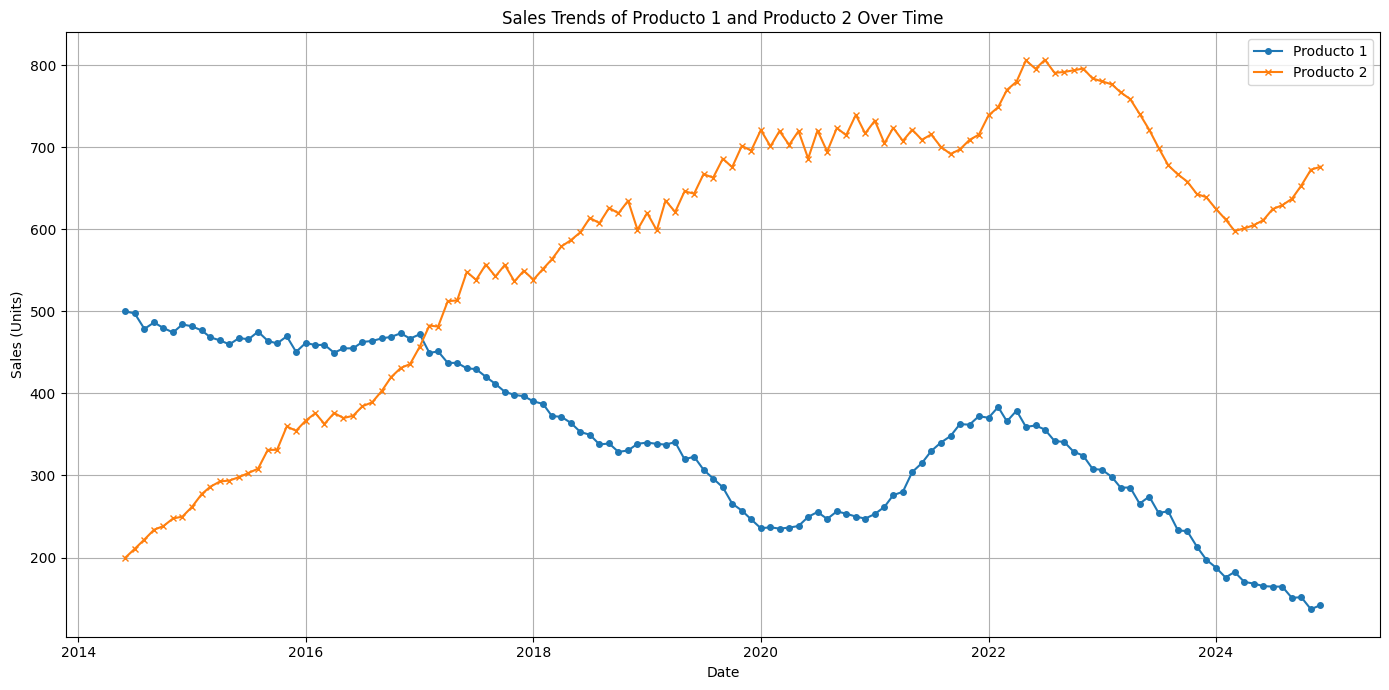

In [20]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['producto1'], label='Producto 1', marker='o', markersize=4)
plt.plot(df.index, df['producto2'], label='Producto 2', marker='x', markersize=4)
plt.title('Sales Trends of Producto 1 and Producto 2 Over Time')
plt.xlabel('Date')
plt.ylabel('Sales (Units)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* **Producto 1**: Esta serie muestra que las ventas están bajando a largo plazo, esta contiene como olas grandes, sube y baja suavemente a lo largo de varios años, teniendo en cuenta lo entendido en clase contiene el factor ciclico y tendencia negativa.

* **Producto 2**: Este producto tiene un comportamiento muy repetitivo donde se observa un periodo de picos, también se puede observar que tiene picos y caídas cada año de forma similar teniendo en cuenta que los últimos años fue muy pronunciada, teniendo en cuenta lo entendido en clase contiene tendencia creciente indicado la tendencia positiva pero en los últimos años combina tendencia positiva a negativa.


Ahora se realizara la descomposicion de las series por cada producto en los componentes principales

* Tendencia
* Estacionalidad
* Residual

Estas nos permitiran dar el primer entendimeinto general de nuetra serie y posibles modelos a aplicar.

Descomposicion del producto estrella 1


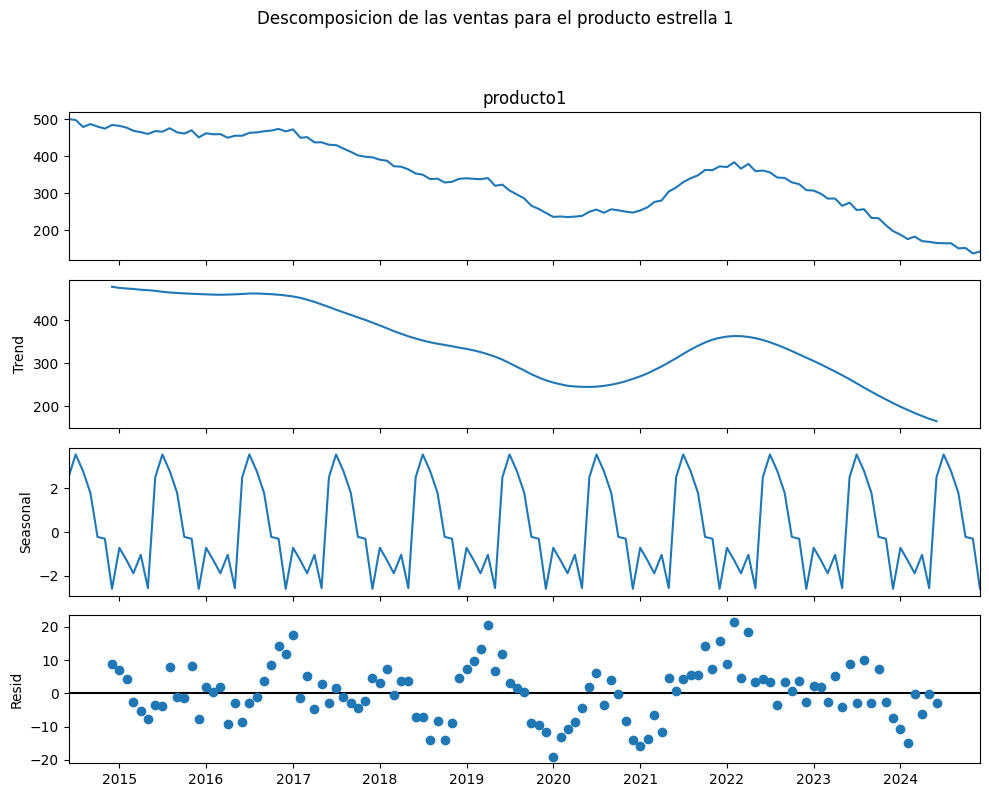

In [21]:
print("Descomposicion del producto estrella 1")
decomposition_p1 = seasonal_decompose(df['producto1'], model='additive', period=12)

fig_p1 = decomposition_p1.plot()
fig_p1.set_size_inches(10, 8)
fig_p1.suptitle('Descomposicion de las ventas para el producto estrella 1', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


Al observar puede evidenciar que las ventas no dependen de días específicos, si no de la economía de las personas que consumen el producto, ya que tiene una tendencia decreciente donde se observa claramente el componente cíclico en los años 2015-2020 y 2020-2022, si observamos sus residuos podemos encontrar autocorrelación..

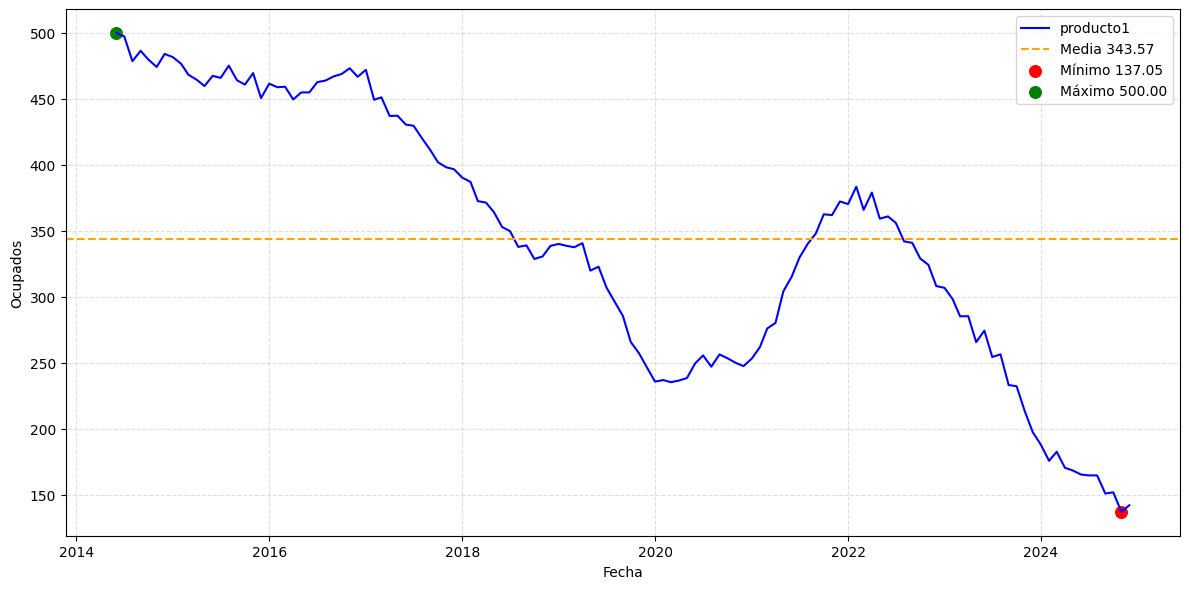

In [22]:
plot_time_series(
    df=df,
    value_col="producto1",
    x_label="Fecha",
    y_label="Ocupados",
    title="",
)

Descomposicion del producto estrella 2


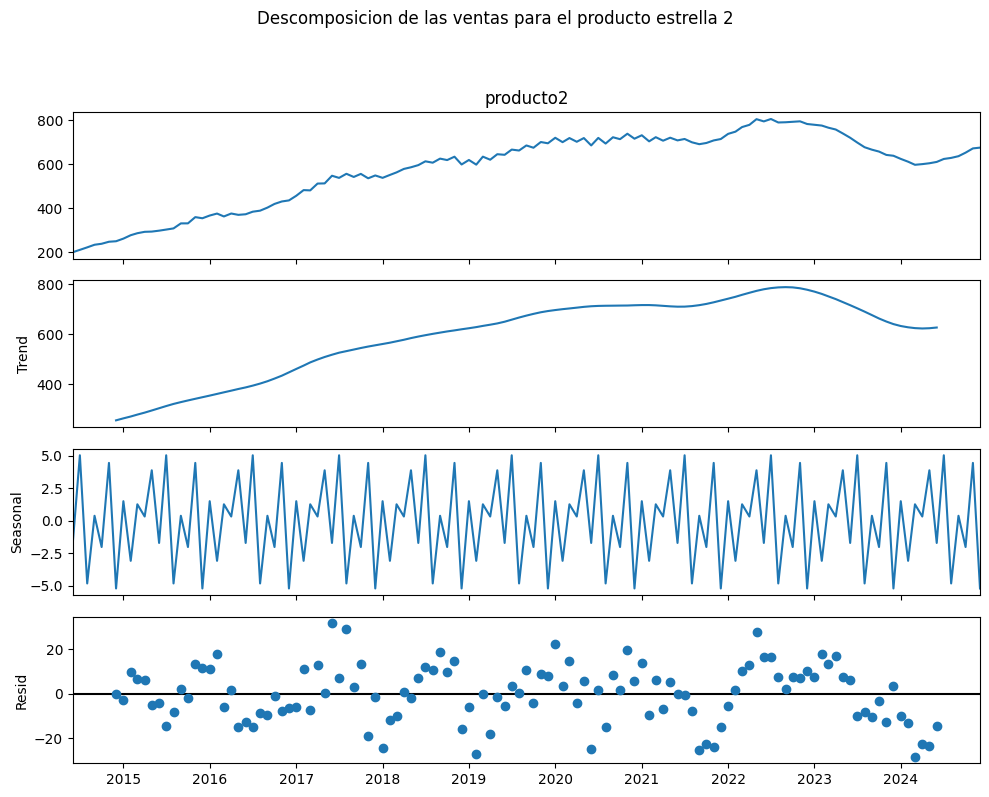

In [23]:
print("Descomposicion del producto estrella 2")
decomposition_p2 = seasonal_decompose(df['producto2'], model='additive', period=12)

fig_p2 = decomposition_p2.plot()
fig_p2.set_size_inches(10, 8)
fig_p2.suptitle('Descomposicion de las ventas para el producto estrella 2', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

nos presenta un crecimiento robusto y sostenido desde 2015 hasta alcanzar su etapa de madurez en 2022, donde se registran los volúmenes máximos de venta cercanos a las 800 unidades. Simultáneamente, se identifica un componente Estacional con un patrón cíclico constante y repetitivo a lo largo de toda la historia del producto, lo que evidencia una recurrencia predecible en los hábitos de compra, aunque de impacto moderado frente al volumen total. Sin embargo, a partir de 2023 se observa un punto de inflexión negativo en la tendencia, indicando que el producto ha entrado en una fase de declive o saturación de mercado, lo que valida la incertidumbre actual y sugiere la necesidad de revisar estrategias ante la caída en la demanda.

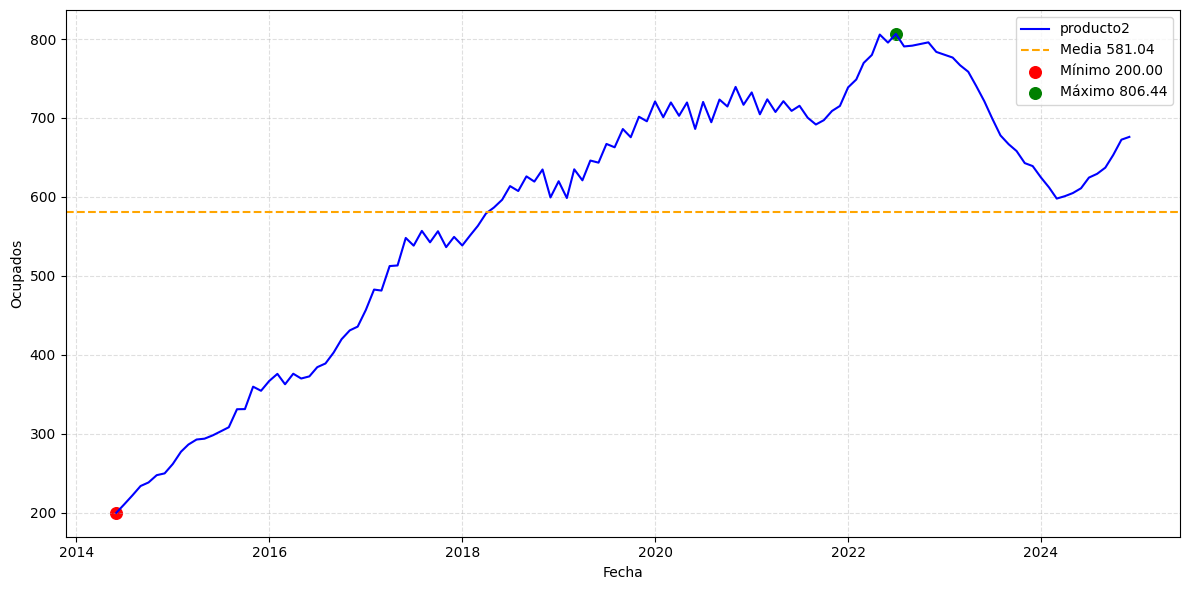

In [24]:
plot_time_series(
    df=df,
    value_col="producto2",
    x_label="Fecha",
    y_label="Ocupados",
    title="",
)

## Conclusiones inciales de los posibles modelos a usar con **Suavizacion exponencial**:

###  **Modelos no recomendados**
* **Promedio movil** no es aplicable debido a que el futuro ya que tiene tendencia, estaciones, además el modelo sigue un promedio que no es adecuado para las predicciones e ignorando su estructura.

* **Suavizacion exponencial simple** no es adecuado debido a que se base en una media constante y aunque el método funciona como un promedio ponderado que asigna peso a las observaciones recientes, no tienen en cuenta la tendencia, lo cual provoca que el pronóstico sea una línea horizontal que no logra capturar el patrón actual de la serie.

* **Suavizacion Exponencial Lineal de Winters (Holt-Winters) aditivo** este modelo no es recomendable ya que la serie no presenta una estacionariedad constante, el cual si lo requiere y es una de sus fortalezas, por ende nos indica que va a introducir ciertas fluctuaciones artificiales en sus predicciones.

* ****

### **Modelos recomendados**
* **La Suavización Exponencial Lineal (Holt)** es un poco más adecuado ya que comienza a capturar la pendiente, es decir nos ayuda a capturar la tendencia, ya que el componente estacional es débil nos permite realizar una mejor estimación.

* **Suavizacion Exponencial Lineal de Winters (Holt-Winters) multiplicactivo** parece ser un buen modelo pero cuando se observa al final que la estacionalidad es debil, este modelo lo que realiza es ajustar la estacionalidad a nivel de serie lo cual es beneficioso los que nos ayuda a reducir el nivel de los picos y puede ser un buen modelo.

## Conclusiones inciales de los posibles modelos a usar con **Encontrando la tendencia y la estacionalidad con modelos de regresion**:

###  **Modelos no recomendados**
* **Modelo de tendencia lineal** si observamos las dos series de tiempo, podemos observar que tenemos tendencia, pero presenta el componente cíclico que puede presentar en un futuro y este se basa en una regresión lineal, lo cual es incapaz de poder capturar el punto de inflexión o cambio de dirección que se puede observar en el patrón de la tendencia.

* **Modelo de tendencia cuadratica** este modelo tiene consideraciones para capturar la estructura general reciente, pero tiene un alto riego en contener un model drifting en proyecciones a mediano plazo ya que la curva o la parábola obliga si o si a tener una caída hasta el infinito negativo lo cual no ayuda a generalizar, lo cual nos deja una clara debilidad en su flexibilidad a cambios en el mercado.

* **Modelo de tendencia polinomica** este modelo lo descartamos ya que presentan sobreajuste cuando intenta generalizar los diferentes patrones, si tenemos un polinomio de grado alto nos ayuda a encontrar los patrones este pierde su capacidad de generalizar y realizando proyecciones no adecuadas en el futuro.

* ****

### **Modelos recomendados**

Por el momento no se tiene una recomendacion.

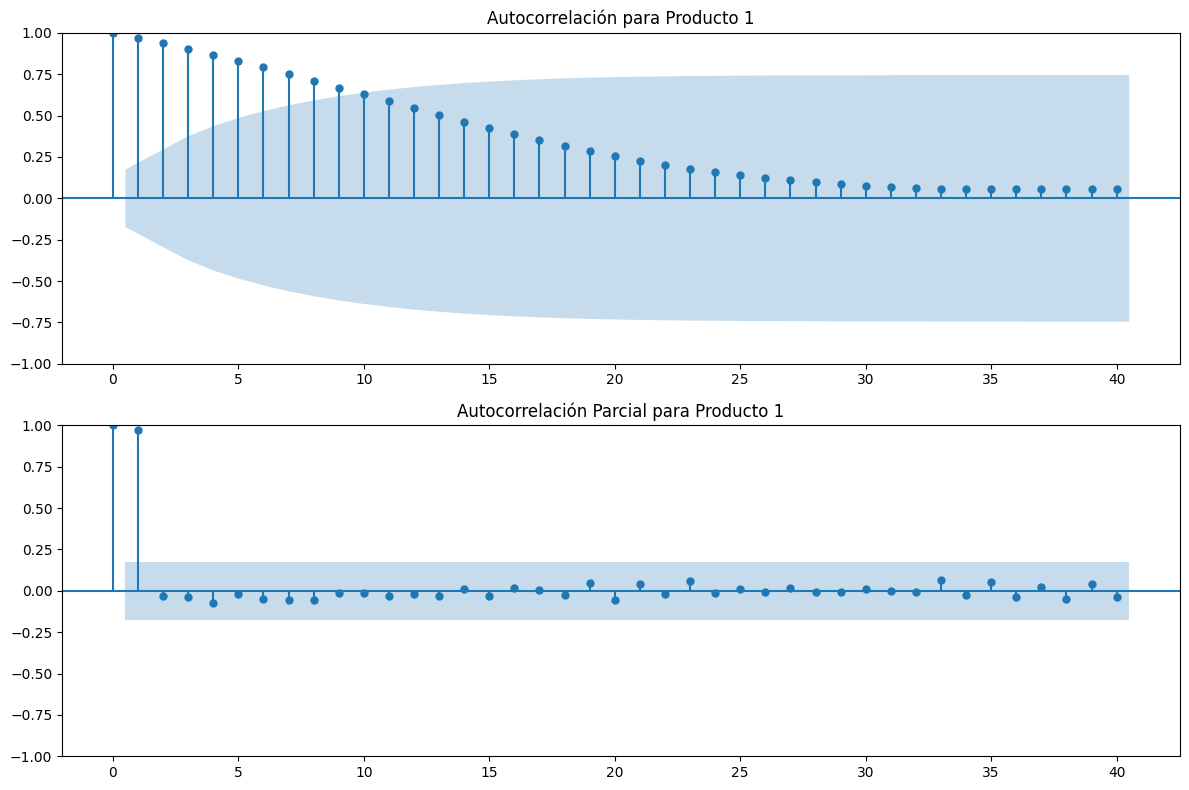

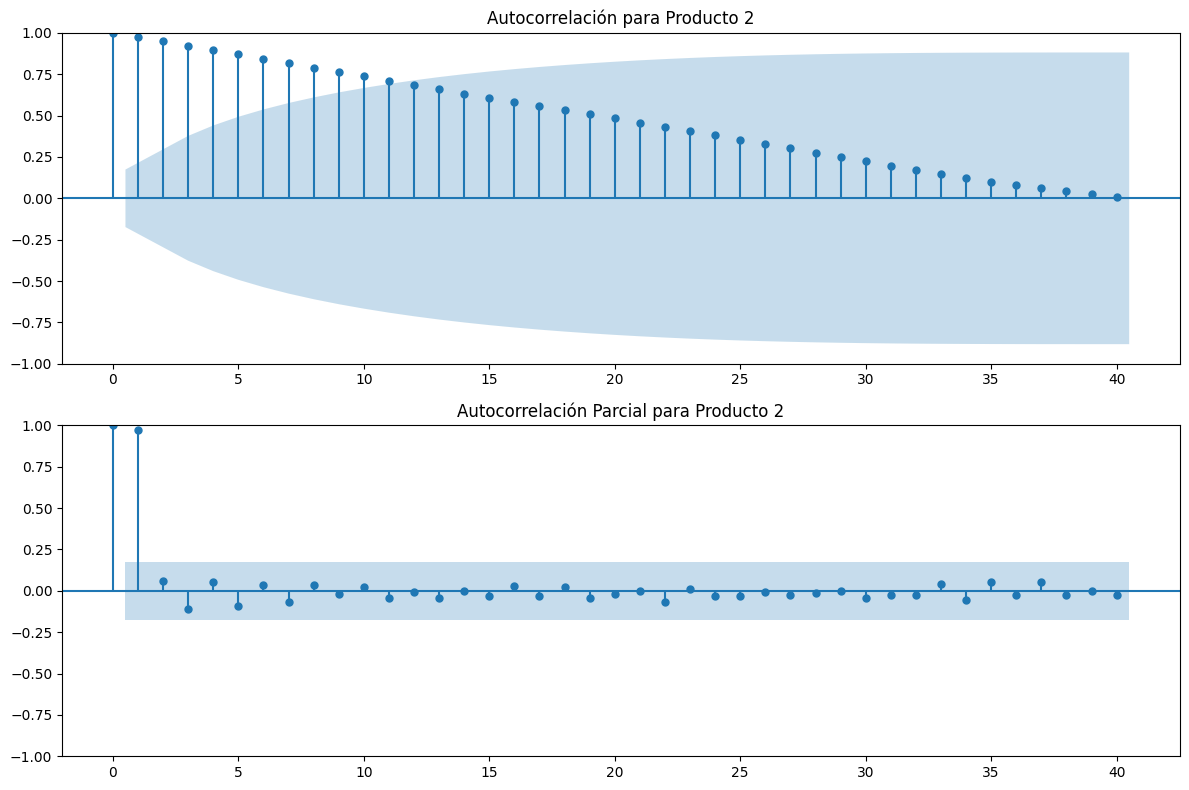

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Gráficos ACF y PACF para Producto 1
plt.figure(figsize=(12, 8))
plt.subplot(211)
plot_acf(df['producto1'], ax=plt.gca(), lags=40, title='Autocorrelación para Producto 1')
plt.subplot(212)
plot_pacf(df['producto1'], ax=plt.gca(), lags=40, title='Autocorrelación Parcial para Producto 1')
plt.tight_layout()
plt.show()

# Gráficos ACF y PACF para Producto 2
plt.figure(figsize=(12, 8))
plt.subplot(211)
plot_acf(df['producto2'], ax=plt.gca(), lags=40, title='Autocorrelación para Producto 2')
plt.subplot(212)
plot_pacf(df['producto2'], ax=plt.gca(), lags=40, title='Autocorrelación Parcial para Producto 2')
plt.tight_layout()
plt.show()

**Producto 1:**

El el gráfico ACF se entiende que tiene una caída muy lenta, donde nos indica que este tiene una influencia mayor con datos históricos, lo cual se requiere al menos una diferencia en el proceso de entrenamiento.

El gráfico PACF tiene un corte abrupto después del primer rezago, lo que nos indica que su dependencia es inmediata.

**Producto 2:**

Tiene un patrón similar al producto 1, el ACF de producto2 también muestra una caída muy lenta compartiendo características y también requiere al menos una diferencia en el proceso de entrenamiento.

El PACF de producto2 nos indica que su predicción está fuertemente influida por los últimos valores de la serie.

**En resumen**, En resumen, ambas series presentan relación fuerte con información histórica, lo que nos indica que no es recomendable solo usar modelo de AR o MA puro debido a que estos modelos necesitan series estacionarias para tener una predicción adecuada la cual no está presente en las series y se sugiere modelos ARIMA para transformar la serie a una forma estacionaria antes de realizar pronósticos.


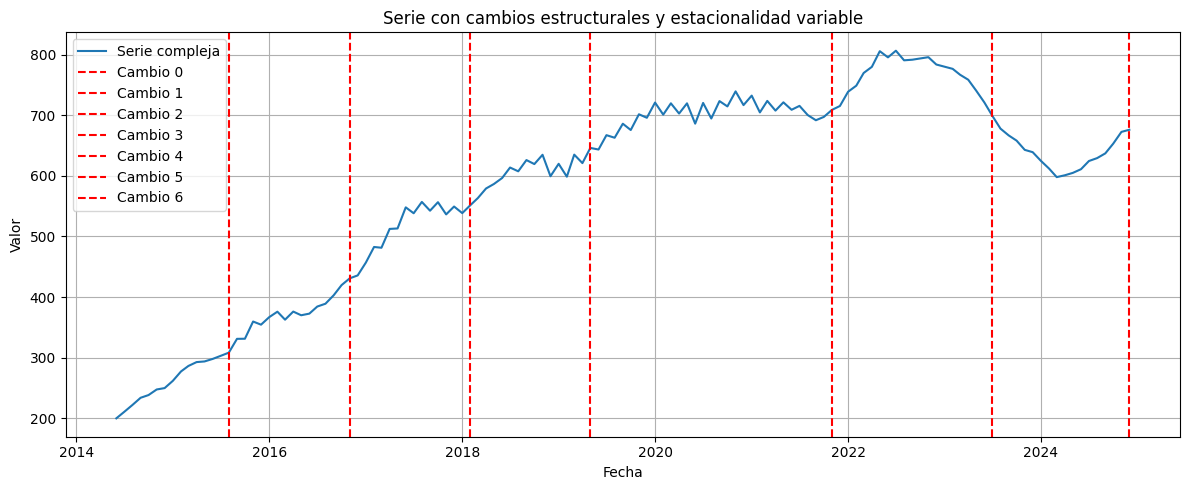

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(df['producto2'], label="Serie compleja")
for idx, c in enumerate(rpt.Pelt(model="rbf").fit(df['producto2'].values).predict(pen=3)):
    plt.axvline(df.index[c-1], color='red', linestyle='--', label=f"Cambio {idx}")
plt.title("Serie con cambios estructurales y estacionalidad variable")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

En la grafica podemos observar una tendencia creciente, lo cual fue segmentada por 6 intercepto de puntos cambiantes de nuestra serie calculada con **ruptures** conteniendo la penalización estricta de 3, donde 0 - 3 se observa su fuerte creciente del producto del mercado y confirmación del éxito del producto, 3 - 5 presenta un crecimiento lento y adopción del producto al producto y su primer saturación en el mercado ya que solo puedo mantenerse y posicionarse, después del cambio 5 presenta una perdida acelerada en el mercado teniendo un rebote o pequeña recuperación donde es un patrón engañoso y muy importante en esta serie.

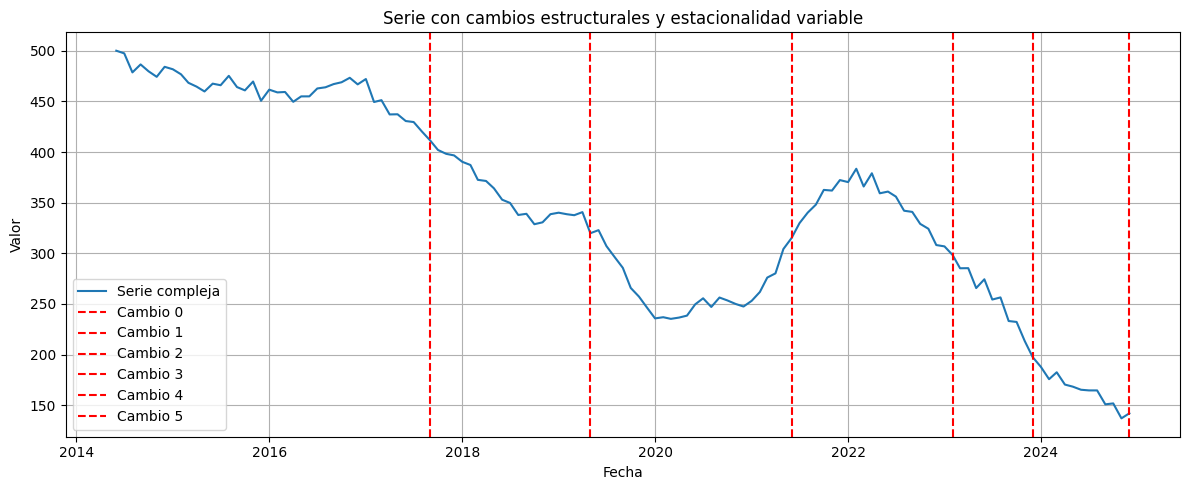

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(df['producto1'], label="Serie compleja")
for idx, c in enumerate(rpt.Pelt(model="rbf").fit(df['producto1'].values).predict(pen=3)):
    plt.axvline(df.index[c-1], color='red', linestyle='--', label=f"Cambio {idx}")
plt.title("Serie con cambios estructurales y estacionalidad variable")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

En la gráfica podemos observar una serie con cambios estructurales y estacionalidad variable, la cual fue segmentada por 5 interceptos de puntos cambiantes calculada con **ruptures**. Se distingue que, desde el inicio hasta el cambio 1, existe una tendencia decreciente marcada, donde los intervalos 0 a 1 muestran una pérdida de valor acelerada. Sin embargo, entre el cambio 1 a 3 se presenta un claro patrón de rebote o fase de recuperación del producto en el mercado, alcanzando picos locales. Finalmente, desde el cambio 3 se presenta nuevamente una caída drástica y sostenida, llevando la serie a sus mínimos históricos hacia el final del periodo observado.

# **Implementacion de modelos**

Primeramente dividiremos los dataset para pode tener train y test para realizar las pruebas iniciales de ambos productos.

In [28]:
df

,producto1,producto2
Date,,
2014-06-01,500.000000,200.000000
2014-07-01,497.400893,210.686220
2014-08-01,478.605317,222.018584
2014-09-01,486.454125,233.920990
2014-10-01,479.695678,238.402098
...,...,...
2024-08-01,164.610771,629.293034
2024-09-01,150.881839,637.099467
2024-10-01,151.788470,653.155282


In [29]:
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import warnings
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


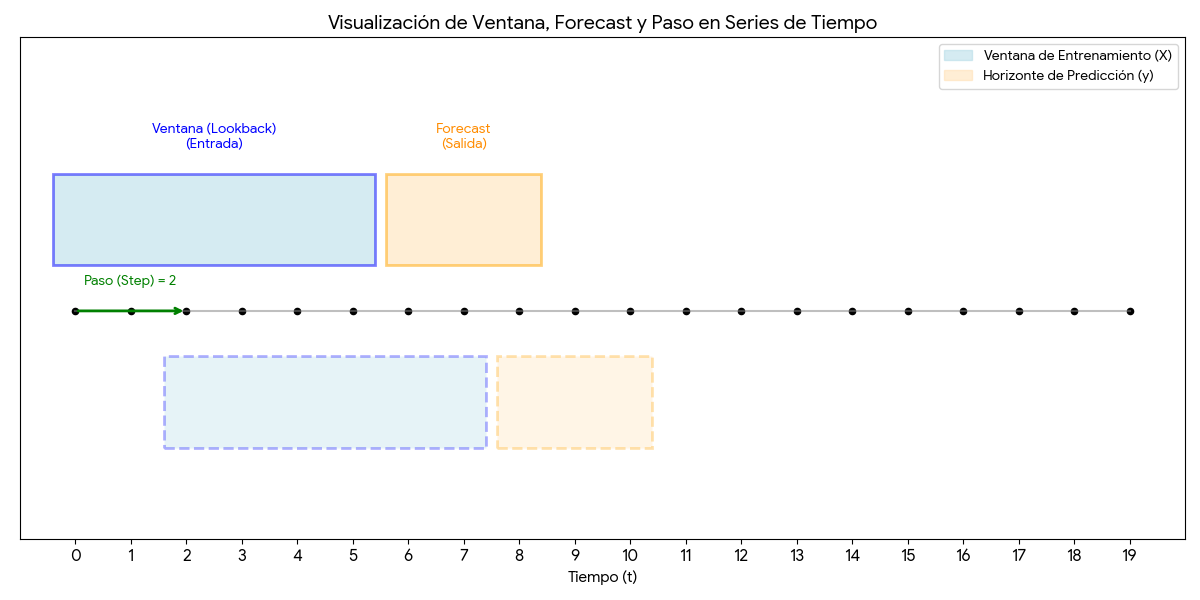

In [30]:
windows_size = 60
horizon_size = 1
step_size = 1
trials_size = 20

Se crean estas variables glovales lo que nos permite un cambio rapido y un test de todos los modelos cumplan siempre con las condiciones minimas para el proceso de seleccion del modelo.

Se eligieron estos valores para el entrenamiento de los modelos ya que permite capturar parte de la historia de todos los proceso y caracteristicas que tiene la serie, esto nos favorece y nos ayuda a tener una mejor prediccion.

**Promedio movil Producto1**

In [31]:
def fore_ma(datos,w,h):
  """
    Genera un pronóstico futuro usando un promedio móvil simple (MA).

    Esta función toma una serie temporal y proyecta 'h' pasos hacia adelante
    aplicando un promedio móvil de ventana 'w'.
    En cada iteración se:
      1. Obtiene la última fecha del índice.
      2. Se genera una nueva fecha sumando 1 mes.
      3. Se asigna como valor el promedio de las últimas 'w' observaciones.

    Args:
        datos (pandas.Series or pandas.DataFrame): Serie temporal con índice de fechas.
            Se recomienda que sea un objeto con un único valor por fecha.
        w (int): Tamaño de la ventana del promedio móvil.
        h (int): Número de periodos futuros a pronosticar.

    Returns:
        pandas.Series or pandas.DataFrame: Las últimas 'h' predicciones generadas
        mediante el promedio móvil.
  """
  data=datos.copy()

  # Generar h pronósticos futuros
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

In [32]:
def evaluar_ma(
    serie,
    window=windows_size,
    horizon=horizon_size,
    step_size=step_size,
    metric='rmse',
    mobile_windows=True
):
    """
    validación valleciana usando promedio móvil.

    Parámetros:
        serie : Serie temporal original (pd.Series o array-like)
        window : tamaño de ventana si se usa ventana móvil
        horizon : pasos adelante que se pronostican en cada iteración
        step_size : salto entre puntos de evaluación (por defecto 1)
        metric : 'rmse' o 'mae'
        mobile_windows :
            True → ventana móvil: últimos 'window' valores
            False → ventana recursiva: toda la historia hasta el punto actual

    Retorna:
        Error global
    """

    # Sanitizar serie
    serie = pd.Series(serie).astype(float).dropna().asfreq('MS')
    n = len(serie)

    predichos = []
    observados = []

    # Iteración walk-forward
    for end_train in range(0, n - horizon, step_size):

        # Selección del conjunto de entrenamiento
        if mobile_windows:
            # Ventana móvil → sólo los últimos 'window'
            start_idx = max(0, end_train - window)
            train = serie.iloc[start_idx:end_train]
        else:
            # Ventana recursiva → desde el inicio
            train = serie.iloc[:end_train]

        test = serie.iloc[end_train:end_train + horizon]

        # Si no hay suficiente test, saltar
        if len(test) < horizon or len(train) == 0:
            continue

        # Pronóstico
        pred = fore_ma(train, window, horizon)

        # Filtrar NaN
        mask = (~pred.isna()) & (~test.isna())
        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask].tolist())
        observados.extend(test[mask].tolist())

    # Si no hubo predicciones válidas
    if len(predichos) == 0:
        return np.inf

    predichos = np.array(predichos)
    observados = np.array(observados)

    # Métrica
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    else:  # mae
        return np.mean(np.abs(observados - predichos))


In [33]:
def objective_ma_mobile_windows(trial, serie):
    """
      Función objetivo para optimización bayesiana de promedio móvil (MA)
      usando Optuna en ventanas móviles.

      Args:
          trial (optuna.trial.Trial): Objeto trial que genera sugerencias de parámetros.
          serie (pandas.Series): Serie temporal original que será evaluada.

      Returns:
          float: RMSE obtenido con la configuración evaluada.
    """
    # Sugerir ventana de promedio móvil
    # window = trial.suggest_int("window", 2, 12)
    # Calcular RMSE
    rmse = evaluar_ma(serie, windows_size, horizon=horizon_size)
    return rmse

def objective_ma_recursive_windows(trial, serie):
    """
      Función objetivo para optimización bayesiana de promedio móvil (MA)
      usando Optuna en ventanas móviles.

      Args:
          trial (optuna.trial.Trial): Objeto trial que genera sugerencias de parámetros.
          serie (pandas.Series): Serie temporal original que será evaluada.

      Returns:
          float: RMSE obtenido con la configuración evaluada.
    """
    # Sugerir ventana de promedio móvil
    # window = trial.suggest_int("window", 2, 12)
    # Calcular RMSE
    rmse = evaluar_ma(serie, windows_size, horizon=horizon_size, mobile_windows=False)
    return rmse


**producto1**

In [34]:
# Crear estudio Optuna
study_ma_mobil = optuna.create_study(direction="minimize")

# Optimizar
study_ma_mobil.optimize(lambda trial: objective_ma_mobile_windows(trial, serie=df['producto1']), n_trials=trials_size)


[I 2025-12-07 00:01:25,666] A new study created in memory with name: no-name-568485f4-e1bb-41d8-a5d1-3ca748faa37b
[I 2025-12-07 00:01:26,083] Trial 0 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:26,357] Trial 1 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:26,742] Trial 2 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:27,255] Trial 3 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:27,643] Trial 4 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:28,053] Trial 5 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:28,490] Trial 6 finished w

In [35]:
plot_ets_rmse_from_study(study_ma_mobil, 'Promedio Mobil - ventana movil producto1')

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 78.8723
  Proceso -> Promedio Mobil - ventana movil producto1:


In [36]:
# Crear estudio Optuna
study_ma_recursive = optuna.create_study(direction="minimize")

# Optimizar
study_ma_recursive.optimize(lambda trial: objective_ma_recursive_windows(trial, serie=df['producto1']), n_trials=trials_size)


[I 2025-12-07 00:01:46,015] A new study created in memory with name: no-name-ecfc0d0e-1276-48c7-b2fe-959ab1fde856
[I 2025-12-07 00:01:46,341] Trial 0 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:46,506] Trial 1 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:46,693] Trial 2 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:46,887] Trial 3 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:47,065] Trial 4 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:47,235] Trial 5 finished with value: 78.8722882514688 and parameters: {}. Best is trial 0 with value: 78.8722882514688.
[I 2025-12-07 00:01:47,405] Trial 6 finished w

In [37]:
plot_ets_rmse_from_study(study_ma_recursive, 'Promedio Mobil - ventana recursiva producto1')

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 78.8723
  Proceso -> Promedio Mobil - ventana recursiva producto1:


In [38]:
view_score_rmse()

,Producto,Ventana,RMSE,Modelo,Parametros
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
1,producto1,Recusiva,78.872288,Promedio Mobil - ventana recursiva producto1,{}


**producto2**

In [39]:
# Crear estudio Optuna
study_ma_mobil = optuna.create_study(direction="minimize")

# Optimizar
study_ma_mobil.optimize(lambda trial: objective_ma_mobile_windows(trial, serie=df['producto2']), n_trials=trials_size)

plot_ets_rmse_from_study(study_ma_recursive, 'Promedio Mobil - ventana movil producto2')

[I 2025-12-07 00:01:49,791] A new study created in memory with name: no-name-903f653a-81c7-4618-a546-b7f2370cfd69
[I 2025-12-07 00:01:49,969] Trial 0 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:50,141] Trial 1 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:50,313] Trial 2 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:50,487] Trial 3 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:50,655] Trial 4 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:50,844] Trial 5 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:51,016] Trial 6 finished w

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 78.8723
  Proceso -> Promedio Mobil - ventana movil producto2:


In [40]:
# Crear estudio Optuna
study_ma_recursive = optuna.create_study(direction="minimize")

# Optimizar
study_ma_recursive.optimize(lambda trial: objective_ma_recursive_windows(trial, serie=df['producto2']), n_trials=trials_size)
plot_ets_rmse_from_study(study_ma_recursive, 'Promedio Mobil - ventana recursiva producto2')


[I 2025-12-07 00:01:53,324] A new study created in memory with name: no-name-ba646c15-65d5-4453-89ce-8f6465fb2d33
[I 2025-12-07 00:01:53,506] Trial 0 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:53,681] Trial 1 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:53,854] Trial 2 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:54,033] Trial 3 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:54,213] Trial 4 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:54,387] Trial 5 finished with value: 136.165971140256 and parameters: {}. Best is trial 0 with value: 136.165971140256.
[I 2025-12-07 00:01:54,563] Trial 6 finished w

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 136.1660
  Proceso -> Promedio Mobil - ventana recursiva producto2:


In [41]:
view_score_rmse()

,Producto,Ventana,RMSE,Modelo,Parametros
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
1,producto1,Recusiva,78.872288,Promedio Mobil - ventana recursiva producto1,{}
2,producto2,Movil,78.872288,Promedio Mobil - ventana movil producto2,{}
3,producto2,Recusiva,136.165971,Promedio Mobil - ventana recursiva producto2,{}


**Modelo de HOLT**

In [42]:
def evaluar_expanding_forecast_holt_winters(
      serie,
      error,
      trend,
      seasonal,
      aplha,
      beta,
      gama,
      window=windows_size,
      step_size=step_size,
      horizon=horizon_size,
      metric='rmse',
      mobile_windows: bool = False,
    ):
    """
    Simula pronósticos autoregresivos en tiempo real con ventana expandida desde el inicio.

    Parámetros:
        serie     : serie temporal (pd.Series o array-like)
        order     : tupla ARIMA (p,d,q)
        window    : cantidad de pronósticos (desde el final hacia atrás)
        step_size : cada cuántos puntos se hace un pronóstico
        horizon   : cuántos pasos adelante predices en cada punto
        metric    : 'rmse' o 'mae'

    Retorna:
        Error promedio global (RMSE o MAE) entre todos los valores predichos vs observados.
    """

    # Asegurar tipo y limpiar NaN de la serie
    serie = pd.Series(serie).astype(float).dropna()
    serie = serie.asfreq('MS')
    n = len(serie)
    predichos = []
    observados = []

    # índices donde termina el conjunto de entrenamiento
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))

    for end_train in puntos_finales:
        train = serie.iloc[end_train + window - n:end_train] if mobile_windows else serie.iloc[:end_train]
        test = serie.iloc[end_train:end_train + horizon]

        if len(test) < horizon:
            continue

        # Si el test ya tiene NaN, lo ignoramos
        if test.isna().any():
            continue

        try:
            model = ETSModel(
                endog=train,
                error=error,
                trend=trend,
                seasonal=seasonal,
                # seasonal_periods=1
            )

            model_fit = model.fit_constrained({
                # 'smoothing_level': aplha,
                # 'smoothing_trend': beta,
                # 'smoothing_seasonal': gama
            })

            pred = model_fit.forecast(steps=horizon)

        except Exception:
            # Si falla el ajuste o el forecast, pasamos a la siguiente ventana
            continue

        # Convertir a Series y filtrar NaN en predicciones
        pred = pd.Series(pred).astype(float)

        # Máscara conjunta para asegurar que ni observados ni predichos tengan NaN
        mask = (~pred.isna()) & (~test.isna())

        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask].tolist())
        observados.extend(test[mask].tolist())

    if len(predichos) == 0:
        return np.inf

    predichos = np.array(predichos, dtype=float)
    observados = np.array(observados, dtype=float)

    mask_finite = (
        np.isfinite(predichos) &
        np.isfinite(observados)
    )

    if mask_finite.sum() == 0:
        return np.inf

    predichos = predichos[mask_finite]
    observados = observados[mask_finite]

    # Cálculo de la métrica
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    elif metric == 'mae':
        return np.mean(np.abs(observados - predichos))
    else:
        raise ValueError("Metric must be 'rmse' or 'mae'")

In [43]:
def objective_holt_winters_mobile_windows(trial, serie, mobile_windows):

    error = trial.suggest_categorical("error", ['add', 'mul'])
    trend = trial.suggest_categorical("trend", ['add', 'mul', None])
    seasonal = trial.suggest_categorical("seasonal", ['add', 'mul', None])

    aplha = trial.suggest_float("aplha", 0.0, 1.0)
    beta = trial.suggest_float("beta", 0.0, 1.0)
    gama = trial.suggest_float("gamma", 0.0, 1.0)

    return evaluar_expanding_forecast_holt_winters(
        serie=serie,
        error=error,
        trend=trend,
        seasonal=seasonal,
        aplha=aplha,
        beta=beta,
        gama=gama,
        window=windows_size,
        step_size=step_size,
        horizon=horizon_size,
        mobile_windows=mobile_windows,
        metric='rmse'
    )

study_holt_winters_mobile_windows = optuna.create_study(direction="minimize")
study_holt_winters_mobile_windows.optimize(
    lambda trial: objective_holt_winters_mobile_windows(trial, df['producto1'], True),
    n_trials=trials_size, n_jobs=-1)

[I 2025-12-07 00:01:57,230] A new study created in memory with name: no-name-3553760c-85fd-4332-8947-0f9c9727016f
[I 2025-12-07 00:02:02,791] Trial 1 finished with value: 8.246064577469106 and parameters: {'error': 'add', 'trend': 'mul', 'seasonal': None, 'aplha': 0.5408940203078912, 'beta': 0.7292205569221633, 'gamma': 0.39662407398263877}. Best is trial 1 with value: 8.246064577469106.
[I 2025-12-07 00:02:13,412] Trial 0 finished with value: 11.790280001549547 and parameters: {'error': 'add', 'trend': None, 'seasonal': 'add', 'aplha': 0.38135923769109603, 'beta': 0.9438375296239883, 'gamma': 0.6262664131634685}. Best is trial 1 with value: 8.246064577469106.
[I 2025-12-07 00:02:17,530] Trial 3 finished with value: 8.701858590524738 and parameters: {'error': 'mul', 'trend': 'add', 'seasonal': None, 'aplha': 0.5225084037047877, 'beta': 0.27170757021515113, 'gamma': 0.2406768677776182}. Best is trial 1 with value: 8.246064577469106.
[I 2025-12-07 00:02:17,796] Trial 2 finished with valu

In [44]:
plot_ets_rmse_from_study(study_holt_winters_mobile_windows, 'ESTModel holt - ventana movil producto1')

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 8.2461
  Proceso -> ESTModel holt - ventana movil producto1:
    error: add
    trend: mul
    seasonal: None
    aplha: 0.5408940203078912
    beta: 0.7292205569221633
    gamma: 0.39662407398263877


In [45]:
study_holt_winters_mobile_windows = optuna.create_study(direction="minimize")
study_holt_winters_mobile_windows.optimize(
    lambda trial: objective_holt_winters_mobile_windows(trial, df['producto1'], False),
    n_trials=trials_size, n_jobs=-1)

plot_ets_rmse_from_study(study_holt_winters_mobile_windows, 'ESTModel holt - ventana recursiva producto1')

[I 2025-12-07 00:03:54,282] A new study created in memory with name: no-name-5a75236e-e2c3-4c15-9e74-514dabadbecc
[I 2025-12-07 00:04:00,238] Trial 0 finished with value: 9.112401663436136 and parameters: {'error': 'add', 'trend': 'add', 'seasonal': None, 'aplha': 0.0463319901411815, 'beta': 0.5640747571420461, 'gamma': 0.275792427443032}. Best is trial 0 with value: 9.112401663436136.
[I 2025-12-07 00:04:13,489] Trial 1 finished with value: 11.513605379725282 and parameters: {'error': 'add', 'trend': None, 'seasonal': 'add', 'aplha': 0.9615107309701219, 'beta': 0.2565143396535233, 'gamma': 0.49922995654273195}. Best is trial 0 with value: 9.112401663436136.
[I 2025-12-07 00:04:17,041] Trial 3 finished with value: 10.825929439944804 and parameters: {'error': 'mul', 'trend': None, 'seasonal': None, 'aplha': 0.4182685762943903, 'beta': 0.798266035593517, 'gamma': 0.5484812461275044}. Best is trial 0 with value: 9.112401663436136.
[I 2025-12-07 00:04:19,165] Trial 2 finished with value: 1

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 8.1945
  Proceso -> ESTModel holt - ventana recursiva producto1:
    error: mul
    trend: mul
    seasonal: None
    aplha: 0.3440718677415586
    beta: 0.597954334862368
    gamma: 0.4784266893962199


In [46]:
study_holt_winters_mobile_windows = optuna.create_study(direction="minimize")
study_holt_winters_mobile_windows.optimize(
    lambda trial: objective_holt_winters_mobile_windows(trial, df['producto2'], True),
    n_trials=trials_size, n_jobs=-1)

plot_ets_rmse_from_study(study_holt_winters_mobile_windows, 'ESTModel holt - ventana movil producto2')


[I 2025-12-07 00:08:56,415] A new study created in memory with name: no-name-453f21cd-35b0-4c94-bf14-7c7153649027
[I 2025-12-07 00:09:01,506] Trial 1 finished with value: 15.812149502164473 and parameters: {'error': 'mul', 'trend': 'add', 'seasonal': None, 'aplha': 0.9205366392504221, 'beta': 0.9136722829537554, 'gamma': 0.1410996568010665}. Best is trial 1 with value: 15.812149502164473.
[I 2025-12-07 00:09:56,207] Trial 2 finished with value: 14.489684248642734 and parameters: {'error': 'add', 'trend': 'add', 'seasonal': 'add', 'aplha': 0.9631842583367579, 'beta': 0.7927585618141351, 'gamma': 0.05496978790136353}. Best is trial 2 with value: 14.489684248642734.
[I 2025-12-07 00:10:01,553] Trial 3 finished with value: 16.419208057536018 and parameters: {'error': 'add', 'trend': None, 'seasonal': None, 'aplha': 0.33065913136239555, 'beta': 0.6309635449991524, 'gamma': 0.12517709326529713}. Best is trial 2 with value: 14.489684248642734.
[I 2025-12-07 00:10:17,720] Trial 0 finished with

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 14.4897
  Proceso -> ESTModel holt - ventana movil producto2:
    error: add
    trend: add
    seasonal: add
    aplha: 0.9631842583367579
    beta: 0.7927585618141351
    gamma: 0.05496978790136353


In [47]:
study_holt_winters_mobile_windows = optuna.create_study(direction="minimize")
study_holt_winters_mobile_windows.optimize(
    lambda trial: objective_holt_winters_mobile_windows(trial, df['producto2'], False),
    n_trials=trials_size, n_jobs=-1)

plot_ets_rmse_from_study(study_holt_winters_mobile_windows, 'ESTModel holt - ventana recursiva producto2')

[I 2025-12-07 00:16:15,752] A new study created in memory with name: no-name-d7bad27e-32b1-40b8-8cc3-08027202047a
[I 2025-12-07 00:16:19,919] Trial 1 finished with value: 15.11942365927118 and parameters: {'error': 'add', 'trend': 'mul', 'seasonal': None, 'aplha': 0.06430085948728614, 'beta': 0.7798527100036148, 'gamma': 0.2278171388296636}. Best is trial 1 with value: 15.11942365927118.
[I 2025-12-07 00:16:20,224] Trial 0 finished with value: 16.46015513167834 and parameters: {'error': 'mul', 'trend': 'add', 'seasonal': None, 'aplha': 0.9386661683774294, 'beta': 0.4324188623713481, 'gamma': 0.1847405138530792}. Best is trial 1 with value: 15.11942365927118.
[I 2025-12-07 00:16:26,741] Trial 3 finished with value: 16.46015513167834 and parameters: {'error': 'mul', 'trend': 'add', 'seasonal': None, 'aplha': 0.5315880508703944, 'beta': 0.6143196235066477, 'gamma': 0.4887181902726504}. Best is trial 1 with value: 15.11942365927118.
[I 2025-12-07 00:16:29,568] Trial 4 finished with value: 

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 14.9041
  Proceso -> ESTModel holt - ventana recursiva producto2:
    error: mul
    trend: mul
    seasonal: None
    aplha: 0.9769261723770496
    beta: 0.4736360652094116
    gamma: 0.2742006320272845


In [48]:
view_score_rmse()

,Producto,Ventana,RMSE,Modelo,Parametros
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."
1,producto1,Recusiva,78.872288,Promedio Mobil - ventana recursiva producto1,{}
6,producto2,Movil,14.489684,ESTModel holt - ventana movil producto2,"{'error': 'add', 'trend': 'add', 'seasonal': '..."
2,producto2,Movil,78.872288,Promedio Mobil - ventana movil producto2,{}
7,producto2,Recusiva,14.904123,ESTModel holt - ventana recursiva producto2,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."
3,producto2,Recusiva,136.165971,Promedio Mobil - ventana recursiva producto2,{}



* M = multiplicativo
* A = aditivo
* N = none / ninguno


**Validacion de descarte de forma general a partir de una tendencia lienal**

In [49]:
import statsmodels.api as sm # prueba de Box-Pierce y la modificación de Ljung-Box


In [50]:
def add_const_fix(x):
    x = np.asarray(x)
    return np.column_stack([np.ones(len(x)), x])


def evaluar_tendencia_lineal(
    serie,
    window=windows_size,
    horizon=horizon_size,
    step_size=step_size,
    metric="rmse",
    mobile_windows=True
):
    """
    Validación walk-forward para tendencia lineal
    con ventana móvil o recursiva.
    """

    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)

    predichos = []
    observados = []

    for t in range(0, n - horizon, step_size):

        # --- Selección de ventana ---
        if mobile_windows:
            start_idx = max(0, t - window)
            y_train = serie.iloc[start_idx:t]
        else:
            y_train = serie.iloc[:t]

        if len(y_train) < 2:
            continue

        # --- Ajuste ---
        x_train = np.arange(len(y_train)) + 1
        X_train = add_const_fix(x_train)

        model = sm.OLS(y_train.values, X_train)
        fit = model.fit()

        # --- Pronóstico ---
        x_fut = np.arange(len(y_train) + 1, len(y_train) + horizon + 1)
        X_fut = add_const_fix(x_fut)
        pred = fit.predict(X_fut)

        y_test = serie.iloc[t:t + horizon]

        mask = (~np.isnan(pred)) & (~y_test.isna())
        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask])
        observados.extend(y_test.values[mask])

    if len(predichos) == 0:
        return np.inf

    if metric == "rmse":
        return np.sqrt(mean_squared_error(observados, predichos))
    else:
        return np.mean(np.abs(observados - predichos))

def objective_tendencia_lineal(trial, serie, mobile_windows):
    # mobile_windows = trial.suggest_categorical("mobile_windows", [True, False])

    error = evaluar_tendencia_lineal(
        serie=serie,
        step_size=step_size,
        metric="rmse",
        mobile_windows=mobile_windows
    )

    return error


def optimizar_tendencia_lineal(serie, n_trials=trials_size, mobile_windows=True):
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda t: objective_tendencia_lineal(t, serie, mobile_windows), n_trials=n_trials)

    print("Mejores parámetros encontrados:")
    print(study.best_params)
    print("Error:", study.best_value)

    return study


**producto1**

In [51]:
study_tendencia_lineal = optimizar_tendencia_lineal(df["producto1"], n_trials=trials_size, mobile_windows=True)
plot_ets_rmse_from_study(study_tendencia_lineal, 'Tendencia lienal - ventana movil  producto1')

[I 2025-12-07 00:20:53,408] A new study created in memory with name: no-name-ffbe57e0-8b6a-4cee-97e8-edf302918a0e
[I 2025-12-07 00:20:53,508] Trial 0 finished with value: 57.70422411213852 and parameters: {}. Best is trial 0 with value: 57.70422411213852.
[I 2025-12-07 00:20:53,616] Trial 1 finished with value: 57.70422411213852 and parameters: {}. Best is trial 0 with value: 57.70422411213852.
[I 2025-12-07 00:20:53,714] Trial 2 finished with value: 57.70422411213852 and parameters: {}. Best is trial 0 with value: 57.70422411213852.
[I 2025-12-07 00:20:53,809] Trial 3 finished with value: 57.70422411213852 and parameters: {}. Best is trial 0 with value: 57.70422411213852.
[I 2025-12-07 00:20:53,902] Trial 4 finished with value: 57.70422411213852 and parameters: {}. Best is trial 0 with value: 57.70422411213852.
[I 2025-12-07 00:20:53,993] Trial 5 finished with value: 57.70422411213852 and parameters: {}. Best is trial 0 with value: 57.70422411213852.
[I 2025-12-07 00:20:54,092] Trial 

Mejores parámetros encontrados:
{}
Error: 57.70422411213852


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 57.7042
  Proceso -> Tendencia lienal - ventana movil  producto1:


In [52]:
study_tendencia_lineal = optimizar_tendencia_lineal(df["producto1"], n_trials=trials_size, mobile_windows=False)
plot_ets_rmse_from_study(study_tendencia_lineal, 'Tendencia lienal - ventana recursiva  producto1')

[I 2025-12-07 00:20:55,361] A new study created in memory with name: no-name-c506a83f-79e5-4e56-a915-034c03bc9c83
[I 2025-12-07 00:20:55,457] Trial 0 finished with value: 50.02110268963394 and parameters: {}. Best is trial 0 with value: 50.02110268963394.
[I 2025-12-07 00:20:55,551] Trial 1 finished with value: 50.02110268963394 and parameters: {}. Best is trial 0 with value: 50.02110268963394.
[I 2025-12-07 00:20:55,655] Trial 2 finished with value: 50.02110268963394 and parameters: {}. Best is trial 0 with value: 50.02110268963394.
[I 2025-12-07 00:20:55,751] Trial 3 finished with value: 50.02110268963394 and parameters: {}. Best is trial 0 with value: 50.02110268963394.
[I 2025-12-07 00:20:55,844] Trial 4 finished with value: 50.02110268963394 and parameters: {}. Best is trial 0 with value: 50.02110268963394.
[I 2025-12-07 00:20:55,936] Trial 5 finished with value: 50.02110268963394 and parameters: {}. Best is trial 0 with value: 50.02110268963394.
[I 2025-12-07 00:20:56,029] Trial 

Mejores parámetros encontrados:
{}
Error: 50.02110268963394


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 50.0211
  Proceso -> Tendencia lienal - ventana recursiva  producto1:


**producto2**

In [53]:
study_tendencia_lineal_p2 = optimizar_tendencia_lineal(df["producto2"], n_trials=trials_size, mobile_windows=True)
plot_ets_rmse_from_study(study_tendencia_lineal_p2, 'Tendencia lienal - ventana movil producto2')

[I 2025-12-07 00:20:57,306] A new study created in memory with name: no-name-c438178d-b567-441e-b846-34b7742b064f
[I 2025-12-07 00:20:57,408] Trial 0 finished with value: 50.03491008510619 and parameters: {}. Best is trial 0 with value: 50.03491008510619.
[I 2025-12-07 00:20:57,504] Trial 1 finished with value: 50.03491008510619 and parameters: {}. Best is trial 0 with value: 50.03491008510619.
[I 2025-12-07 00:20:57,601] Trial 2 finished with value: 50.03491008510619 and parameters: {}. Best is trial 0 with value: 50.03491008510619.
[I 2025-12-07 00:20:57,711] Trial 3 finished with value: 50.03491008510619 and parameters: {}. Best is trial 0 with value: 50.03491008510619.
[I 2025-12-07 00:20:57,809] Trial 4 finished with value: 50.03491008510619 and parameters: {}. Best is trial 0 with value: 50.03491008510619.
[I 2025-12-07 00:20:57,903] Trial 5 finished with value: 50.03491008510619 and parameters: {}. Best is trial 0 with value: 50.03491008510619.
[I 2025-12-07 00:20:57,996] Trial 

Mejores parámetros encontrados:
{}
Error: 50.03491008510619


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 50.0349
  Proceso -> Tendencia lienal - ventana movil producto2:


In [54]:
study_tendencia_lineal = optimizar_tendencia_lineal(df["producto2"], n_trials=trials_size, mobile_windows=False)
plot_ets_rmse_from_study(study_tendencia_lineal, 'Tendencia lienal - ventana recursiva  producto2')

[I 2025-12-07 00:20:59,277] A new study created in memory with name: no-name-e8216911-00b1-436d-bd66-cd47dfe6452a
[I 2025-12-07 00:20:59,388] Trial 0 finished with value: 91.9096374270612 and parameters: {}. Best is trial 0 with value: 91.9096374270612.
[I 2025-12-07 00:20:59,486] Trial 1 finished with value: 91.9096374270612 and parameters: {}. Best is trial 0 with value: 91.9096374270612.
[I 2025-12-07 00:20:59,593] Trial 2 finished with value: 91.9096374270612 and parameters: {}. Best is trial 0 with value: 91.9096374270612.
[I 2025-12-07 00:20:59,689] Trial 3 finished with value: 91.9096374270612 and parameters: {}. Best is trial 0 with value: 91.9096374270612.
[I 2025-12-07 00:20:59,797] Trial 4 finished with value: 91.9096374270612 and parameters: {}. Best is trial 0 with value: 91.9096374270612.
[I 2025-12-07 00:20:59,894] Trial 5 finished with value: 91.9096374270612 and parameters: {}. Best is trial 0 with value: 91.9096374270612.
[I 2025-12-07 00:20:59,992] Trial 6 finished w

Mejores parámetros encontrados:
{}
Error: 91.9096374270612


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 91.9096
  Proceso -> Tendencia lienal - ventana recursiva  producto2:


In [55]:
view_score_rmse()

,Producto,Ventana,RMSE,Modelo,Parametros
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
8,producto1,Movil,57.704224,Tendencia lienal - ventana movil producto1,{}
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."
9,producto1,Recusiva,50.021103,Tendencia lienal - ventana recursiva producto1,{}
1,producto1,Recusiva,78.872288,Promedio Mobil - ventana recursiva producto1,{}
6,producto2,Movil,14.489684,ESTModel holt - ventana movil producto2,"{'error': 'add', 'trend': 'add', 'seasonal': '..."
10,producto2,Movil,50.034910,Tendencia lienal - ventana movil producto2,{}
2,producto2,Movil,78.872288,Promedio Mobil - ventana movil producto2,{}
7,producto2,Recusiva,14.904123,ESTModel holt - ventana recursiva producto2,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."


**Validacion de modelos de tendencia cuadratica**

In [56]:
def matriz_polinomica(x, grado):
    """
    Genera matriz polinómica:
    [1, t, t^2, ..., t^grado]
    """
    x = np.asarray(x)
    return np.column_stack([x**n for n in range(grado + 1)])

In [57]:
def evaluar_tendencia_polinomica(
    serie,
    grado=2,
    window=windows_size,
    horizon=horizon_size,
    step_size=step_size,
    metric="rmse",
    mobile_windows=True
):

    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)

    predichos = []
    observados = []

    for t in range(0, n - horizon, step_size):

        # --- Selección de ventana ---
        if mobile_windows:
            start = max(0, t - window)
            y_train = serie.iloc[start:t]
        else:
            y_train = serie.iloc[:t]

        # Se requieren al menos grado+1 puntos
        if len(y_train) < grado + 1:
            continue

        # ---- Construcción matriz X entrenamiento ----
        x_train = np.arange(1, len(y_train) + 1)
        X_train = matriz_polinomica(x_train, grado)

        modelo = sm.OLS(y_train.values, X_train)
        ajuste = modelo.fit()

        # ---- X futuro ----
        x_fut = np.arange(len(y_train) + 1, len(y_train) + horizon + 1)
        X_fut = matriz_polinomica(x_fut, grado)

        # ---- Predicción ----
        pred = ajuste.predict(X_fut)
        y_test = serie.iloc[t:t + horizon]

        mask = (~np.isnan(pred)) & (~y_test.isna())
        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask])
        observados.extend(y_test.values[mask])

    if len(predichos) == 0:
        return np.inf

    if metric == "rmse":
        return np.sqrt(mean_squared_error(observados, predichos))
    else:
        return np.mean(np.abs(observados - predichos))


In [58]:
def objective_polinomico(trial, serie, mobile_windows):

    grado = trial.suggest_int("grado", 2, 20)
    # mobile_windows = trial.suggest_categorical("mobile_windows", [True, False])

    return evaluar_tendencia_polinomica(
        serie=serie,
        grado=grado,
        window=windows_size,
        step_size=step_size,
        metric="rmse",
        mobile_windows=mobile_windows
    )


In [59]:
def optimizar_tendencia_polinomica(serie, n_trials=trials_size, mobile_windows=True):

    study = optuna.create_study(direction="minimize")

    study.optimize(
        lambda trial: objective_polinomico(trial, serie, mobile_windows),
        n_trials=n_trials
    )

    print("Mejores parámetros:")
    print(study.best_params)
    print("Error mínimo:", study.best_value)

    return study


**Producto 1**

In [60]:
study_tendencia_cuadratica = optimizar_tendencia_polinomica(
    serie=df["producto1"],
    n_trials=trials_size,
    mobile_windows=True
)
plot_ets_rmse_from_study(study_tendencia_cuadratica, 'Tendencia lienal - ventana movil producto1')

[I 2025-12-07 00:21:01,339] A new study created in memory with name: no-name-98e35017-b50d-4fe8-8f0a-7c4347bc6f24
[I 2025-12-07 00:21:01,446] Trial 0 finished with value: 30.554400371770104 and parameters: {'grado': 4}. Best is trial 0 with value: 30.554400371770104.
[I 2025-12-07 00:21:01,543] Trial 1 finished with value: 30.554400371770104 and parameters: {'grado': 4}. Best is trial 0 with value: 30.554400371770104.
[I 2025-12-07 00:21:01,645] Trial 2 finished with value: 454.0767701462568 and parameters: {'grado': 10}. Best is trial 0 with value: 30.554400371770104.
[I 2025-12-07 00:21:01,756] Trial 3 finished with value: 90523209.42092003 and parameters: {'grado': 20}. Best is trial 0 with value: 30.554400371770104.
[I 2025-12-07 00:21:01,860] Trial 4 finished with value: 52.618938439297416 and parameters: {'grado': 7}. Best is trial 0 with value: 30.554400371770104.
[I 2025-12-07 00:21:01,960] Trial 5 finished with value: 52.618938439297416 and parameters: {'grado': 7}. Best is tr

Mejores parámetros:
{'grado': 4}
Error mínimo: 30.554400371770104


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 30.5544
  Proceso -> Tendencia lienal - ventana movil producto1:
    grado: 4


In [61]:
study_tendencia_cuadratica = optimizar_tendencia_polinomica(
    serie=df["producto1"],
    n_trials=trials_size,
    mobile_windows=False
)
plot_ets_rmse_from_study(study_tendencia_cuadratica, 'Tendencia lienal - ventana recursiva producto1')

[I 2025-12-07 00:21:03,571] A new study created in memory with name: no-name-d018dffc-9106-42a6-b987-88863f9047f8
[I 2025-12-07 00:21:03,707] Trial 0 finished with value: 45.065128341366986 and parameters: {'grado': 6}. Best is trial 0 with value: 45.065128341366986.
[I 2025-12-07 00:21:03,854] Trial 1 finished with value: 517818030.85291547 and parameters: {'grado': 16}. Best is trial 0 with value: 45.065128341366986.
[I 2025-12-07 00:21:03,987] Trial 2 finished with value: 45.065128341366986 and parameters: {'grado': 6}. Best is trial 0 with value: 45.065128341366986.
[I 2025-12-07 00:21:04,129] Trial 3 finished with value: 12688359.784814795 and parameters: {'grado': 12}. Best is trial 0 with value: 45.065128341366986.
[I 2025-12-07 00:21:04,281] Trial 4 finished with value: 86161981.3948838 and parameters: {'grado': 18}. Best is trial 0 with value: 45.065128341366986.
[I 2025-12-07 00:21:04,417] Trial 5 finished with value: 128.39969050569204 and parameters: {'grado': 8}. Best is t

Mejores parámetros:
{'grado': 4}
Error mínimo: 40.398241229920146


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 40.3982
  Proceso -> Tendencia lienal - ventana recursiva producto1:
    grado: 4


**Producto 2**

In [62]:
study_tendencia_cuadratica = optimizar_tendencia_polinomica(
    serie=df["producto2"],
    n_trials=trials_size,
    mobile_windows=True
)
plot_ets_rmse_from_study(study_tendencia_cuadratica, 'Tendencia lienal - ventana movil producto2')

[I 2025-12-07 00:21:06,282] A new study created in memory with name: no-name-ce7406a9-1a63-456d-bcba-910aa98f5334
[I 2025-12-07 00:21:06,398] Trial 0 finished with value: 44131057.21699256 and parameters: {'grado': 18}. Best is trial 0 with value: 44131057.21699256.
[I 2025-12-07 00:21:06,500] Trial 1 finished with value: 3803112.887276685 and parameters: {'grado': 11}. Best is trial 1 with value: 3803112.887276685.
[I 2025-12-07 00:21:06,619] Trial 2 finished with value: 44.60977397520134 and parameters: {'grado': 7}. Best is trial 2 with value: 44.60977397520134.
[I 2025-12-07 00:21:06,719] Trial 3 finished with value: 3803112.887276685 and parameters: {'grado': 11}. Best is trial 2 with value: 44.60977397520134.
[I 2025-12-07 00:21:06,815] Trial 4 finished with value: 44.60977397520134 and parameters: {'grado': 7}. Best is trial 2 with value: 44.60977397520134.
[I 2025-12-07 00:21:06,924] Trial 5 finished with value: 43921422.64250234 and parameters: {'grado': 19}. Best is trial 2 w

Mejores parámetros:
{'grado': 5}
Error mínimo: 30.870635390396277


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 30.8706
  Proceso -> Tendencia lienal - ventana movil producto2:
    grado: 5


In [63]:
study_tendencia_cuadratica = optimizar_tendencia_polinomica(
    serie=df["producto2"],
    n_trials=trials_size,
    mobile_windows=False
)
plot_ets_rmse_from_study(study_tendencia_cuadratica, 'Tendencia lienal - ventana recursiva producto2')

[I 2025-12-07 00:21:08,369] A new study created in memory with name: no-name-492844a8-6938-4d0e-8642-1b6e28c04f80
[I 2025-12-07 00:21:08,479] Trial 0 finished with value: 6970246.65468087 and parameters: {'grado': 12}. Best is trial 0 with value: 6970246.65468087.
[I 2025-12-07 00:21:08,589] Trial 1 finished with value: 391218125.4304862 and parameters: {'grado': 17}. Best is trial 0 with value: 6970246.65468087.
[I 2025-12-07 00:21:08,692] Trial 2 finished with value: 3898939.480220419 and parameters: {'grado': 11}. Best is trial 2 with value: 3898939.480220419.
[I 2025-12-07 00:21:08,798] Trial 3 finished with value: 181124425.8356734 and parameters: {'grado': 15}. Best is trial 2 with value: 3898939.480220419.
[I 2025-12-07 00:21:08,894] Trial 4 finished with value: 37.11232294439865 and parameters: {'grado': 5}. Best is trial 4 with value: 37.11232294439865.
[I 2025-12-07 00:21:08,989] Trial 5 finished with value: 36.46316031082941 and parameters: {'grado': 2}. Best is trial 5 with

Mejores parámetros:
{'grado': 3}
Error mínimo: 32.1421548235265


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 32.1422
  Proceso -> Tendencia lienal - ventana recursiva producto2:
    grado: 3


In [64]:
view_score_rmse()

,Producto,Ventana,RMSE,Modelo,Parametros
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
12,producto1,Movil,30.554400,Tendencia lienal - ventana movil producto1,{'grado': 4}
8,producto1,Movil,57.704224,Tendencia lienal - ventana movil producto1,{}
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."
13,producto1,Recusiva,40.398241,Tendencia lienal - ventana recursiva producto1,{'grado': 4}
9,producto1,Recusiva,50.021103,Tendencia lienal - ventana recursiva producto1,{}
1,producto1,Recusiva,78.872288,Promedio Mobil - ventana recursiva producto1,{}
6,producto2,Movil,14.489684,ESTModel holt - ventana movil producto2,"{'error': 'add', 'trend': 'add', 'seasonal': '..."
10,producto2,Movil,30.870635,Tendencia lienal - ventana movil producto2,{'grado': 5}


**A continuacion se validara tendencia lineal que incorpore estacionalidad mediante dummies de mes**

In [65]:
def add_const_and_dummies(x, month_dummies_subset):
    """
    Combina constante, tendencia lineal y estacionalidad (month dummies)
    """
    x = np.asarray(x)
    X = np.column_stack([np.ones(len(x)), x])  # constante + tendencia
    if month_dummies_subset is not None and len(month_dummies_subset) > 0:
        X = np.column_stack([X, month_dummies_subset.values])
    return X

def evaluar_tendencia_lineal_estacionalidad(
    serie,
    month_dummies,
    window=windows_size,
    horizon=horizon_size,
    step_size=step_size,
    metric="rmse",
    mobile_windows=True
):
    """
    Validación walk-forward para tendencia lineal
    con estacionalidad y ventana móvil o recursiva.
    """

    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)

    predichos = []
    observados = []

    for t in range(0, n - horizon, step_size):

        # --- Selección de ventana ---
        if mobile_windows:
            start_idx = max(0, t - window)
            y_train = serie.iloc[start_idx:t]
            month_train = month_dummies.iloc[start_idx:t, :]
        else:
            y_train = serie.iloc[:t]
            month_train = month_dummies.iloc[:t, :]

        if len(y_train) < 2:
            continue

        # --- Ajuste ---
        x_train = np.arange(len(y_train)) + 1
        X_train = add_const_and_dummies(x_train, month_train)

        model = sm.OLS(y_train.values, X_train)
        fit = model.fit()

        # --- Pronóstico ---
        x_fut = np.arange(len(y_train) + 1, len(y_train) + horizon + 1)
        if mobile_windows:
            month_fut = month_dummies.iloc[t:t + horizon, :]
        else:
            month_fut = month_dummies.iloc[t:t + horizon, :]

        X_fut = add_const_and_dummies(x_fut, month_fut)
        pred = fit.predict(X_fut)

        y_test = serie.iloc[t:t + horizon]

        mask = (~np.isnan(pred)) & (~y_test.isna())
        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask])
        observados.extend(y_test.values[mask])

    if len(predichos) == 0:
        return np.inf

    if metric == "rmse":
        return np.sqrt(mean_squared_error(observados, predichos))
    else:
        return np.mean(np.abs(observados - predichos))


def objective_tendencia_lineal_estacional(trial, serie, month_dummies, mobile_windows):
    # mobile_windows = trial.suggest_categorical("mobile_windows", [True, False])
    # horizon = trial.suggest_int("horizon", 1, 3)

    return evaluar_tendencia_lineal_estacionalidad(
        serie=serie,
        month_dummies=month_dummies,
        window=windows_size,
        horizon=horizon_size,
        step_size=step_size,
        metric="rmse",
        mobile_windows=mobile_windows
    )


def optimizar_tendencia_lineal_estacionalidad(serie, month_dummies, mobile_windows):

    study = optuna.create_study(direction="minimize")

    study.optimize(
        lambda trial: objective_tendencia_lineal_estacional(trial, serie, month_dummies, mobile_windows),
        n_trials=trials_size
    )

    print("Mejores parámetros encontrados:")
    print(study.best_params)
    print("Error mínimo:", study.best_value)

    return study


**producto 1**

In [66]:
month_dummies = pd.get_dummies(df.index.month, drop_first=True, dtype=float)
month_dummies = month_dummies.set_index(df.index)

In [67]:
month_dummies

,2,3,4,5,6,7,8,9,10,11,12
Date,,,,,,,,,,,
2014-06-01,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-07-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2014-08-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2014-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2014-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2024-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2024-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [68]:
study_tendencia_lineal_estacionalidad = optimizar_tendencia_lineal_estacionalidad(
    serie=df["producto1"],
    month_dummies=month_dummies,
    mobile_windows=True
)
plot_ets_rmse_from_study(study_tendencia_lineal_estacionalidad, 'Tendencia lineal que incorpore estacionalidad mediante dummies de mes - ventana movil producto1')

[I 2025-12-07 00:21:10,561] A new study created in memory with name: no-name-aa50f7fc-fa8c-4d0e-a725-016674568f58
[I 2025-12-07 00:21:10,703] Trial 0 finished with value: 75.7578001633884 and parameters: {}. Best is trial 0 with value: 75.7578001633884.
[I 2025-12-07 00:21:10,838] Trial 1 finished with value: 75.7578001633884 and parameters: {}. Best is trial 0 with value: 75.7578001633884.
[I 2025-12-07 00:21:10,971] Trial 2 finished with value: 75.7578001633884 and parameters: {}. Best is trial 0 with value: 75.7578001633884.
[I 2025-12-07 00:21:11,105] Trial 3 finished with value: 75.7578001633884 and parameters: {}. Best is trial 0 with value: 75.7578001633884.
[I 2025-12-07 00:21:11,241] Trial 4 finished with value: 75.7578001633884 and parameters: {}. Best is trial 0 with value: 75.7578001633884.
[I 2025-12-07 00:21:11,380] Trial 5 finished with value: 75.7578001633884 and parameters: {}. Best is trial 0 with value: 75.7578001633884.
[I 2025-12-07 00:21:11,508] Trial 6 finished w

Mejores parámetros encontrados:
{}
Error mínimo: 75.7578001633884


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 75.7578
  Proceso -> Tendencia lineal que incorpore estacionalidad mediante dummies de mes - ventana movil producto1:


In [69]:
study_tendencia_lineal_estacionalidad = optimizar_tendencia_lineal_estacionalidad(
    serie=df["producto1"],
    month_dummies=month_dummies,
    mobile_windows=False
)
plot_ets_rmse_from_study(study_tendencia_lineal_estacionalidad, 'Tendencia lineal que incorpore estacionalidad mediante dummies de mes - ventana recursiva producto1')

[I 2025-12-07 00:21:13,275] A new study created in memory with name: no-name-807fa60d-1a2c-42b0-abd3-8a10441a82c5
[I 2025-12-07 00:21:13,426] Trial 0 finished with value: 67.24447941805388 and parameters: {}. Best is trial 0 with value: 67.24447941805388.
[I 2025-12-07 00:21:13,563] Trial 1 finished with value: 67.24447941805388 and parameters: {}. Best is trial 0 with value: 67.24447941805388.
[I 2025-12-07 00:21:13,698] Trial 2 finished with value: 67.24447941805388 and parameters: {}. Best is trial 0 with value: 67.24447941805388.
[I 2025-12-07 00:21:13,829] Trial 3 finished with value: 67.24447941805388 and parameters: {}. Best is trial 0 with value: 67.24447941805388.
[I 2025-12-07 00:21:13,963] Trial 4 finished with value: 67.24447941805388 and parameters: {}. Best is trial 0 with value: 67.24447941805388.
[I 2025-12-07 00:21:14,094] Trial 5 finished with value: 67.24447941805388 and parameters: {}. Best is trial 0 with value: 67.24447941805388.
[I 2025-12-07 00:21:14,230] Trial 

Mejores parámetros encontrados:
{}
Error mínimo: 67.24447941805388


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 67.2445
  Proceso -> Tendencia lineal que incorpore estacionalidad mediante dummies de mes - ventana recursiva producto1:


**producto 2**

In [70]:
study_tendencia_lineal_estacionalidad = optimizar_tendencia_lineal_estacionalidad(
    serie=df["producto2"],
    month_dummies=month_dummies,
    mobile_windows=True
)
plot_ets_rmse_from_study(study_tendencia_lineal_estacionalidad, 'Tendencia lineal que incorpore estacionalidad mediante dummies de mes - ventana movil producto2')

[I 2025-12-07 00:21:16,094] A new study created in memory with name: no-name-8f9eb403-c1fa-47a0-9d4a-68358d515109
[I 2025-12-07 00:21:16,277] Trial 0 finished with value: 54.412093621504894 and parameters: {}. Best is trial 0 with value: 54.412093621504894.
[I 2025-12-07 00:21:16,448] Trial 1 finished with value: 54.412093621504894 and parameters: {}. Best is trial 0 with value: 54.412093621504894.
[I 2025-12-07 00:21:16,636] Trial 2 finished with value: 54.412093621504894 and parameters: {}. Best is trial 0 with value: 54.412093621504894.
[I 2025-12-07 00:21:16,809] Trial 3 finished with value: 54.412093621504894 and parameters: {}. Best is trial 0 with value: 54.412093621504894.
[I 2025-12-07 00:21:16,984] Trial 4 finished with value: 54.412093621504894 and parameters: {}. Best is trial 0 with value: 54.412093621504894.
[I 2025-12-07 00:21:17,152] Trial 5 finished with value: 54.412093621504894 and parameters: {}. Best is trial 0 with value: 54.412093621504894.
[I 2025-12-07 00:21:17

Mejores parámetros encontrados:
{}
Error mínimo: 54.412093621504894


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 54.4121
  Proceso -> Tendencia lineal que incorpore estacionalidad mediante dummies de mes - ventana movil producto2:


In [71]:
study_tendencia_lineal_estacionalidad = optimizar_tendencia_lineal_estacionalidad(
    serie=df["producto2"],
    month_dummies=month_dummies,
    mobile_windows=False
)
plot_ets_rmse_from_study(study_tendencia_lineal_estacionalidad, 'Tendencia lineal que incorpore estacionalidad mediante dummies de mes - ventana recursiva producto2')

[I 2025-12-07 00:21:19,424] A new study created in memory with name: no-name-15ebb8f0-c1dd-459e-9169-16635bb50233
[I 2025-12-07 00:21:19,566] Trial 0 finished with value: 97.75168338952163 and parameters: {}. Best is trial 0 with value: 97.75168338952163.
[I 2025-12-07 00:21:19,727] Trial 1 finished with value: 97.75168338952163 and parameters: {}. Best is trial 0 with value: 97.75168338952163.
[I 2025-12-07 00:21:19,858] Trial 2 finished with value: 97.75168338952163 and parameters: {}. Best is trial 0 with value: 97.75168338952163.
[I 2025-12-07 00:21:19,988] Trial 3 finished with value: 97.75168338952163 and parameters: {}. Best is trial 0 with value: 97.75168338952163.
[I 2025-12-07 00:21:20,122] Trial 4 finished with value: 97.75168338952163 and parameters: {}. Best is trial 0 with value: 97.75168338952163.
[I 2025-12-07 00:21:20,257] Trial 5 finished with value: 97.75168338952163 and parameters: {}. Best is trial 0 with value: 97.75168338952163.
[I 2025-12-07 00:21:20,391] Trial 

Mejores parámetros encontrados:
{}
Error mínimo: 97.75168338952163


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 97.7517
  Proceso -> Tendencia lineal que incorpore estacionalidad mediante dummies de mes - ventana recursiva producto2:


In [72]:
view_score_rmse()

,Producto,Ventana,RMSE,Modelo,Parametros
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
12,producto1,Movil,30.554400,Tendencia lienal - ventana movil producto1,{'grado': 4}
8,producto1,Movil,57.704224,Tendencia lienal - ventana movil producto1,{}
15,producto1,Movil,75.757800,Tendencia lineal que incorpore estacionalidad ...,{}
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."
13,producto1,Recusiva,40.398241,Tendencia lienal - ventana recursiva producto1,{'grado': 4}
9,producto1,Recusiva,50.021103,Tendencia lienal - ventana recursiva producto1,{}
16,producto1,Recusiva,67.244479,Tendencia lineal que incorpore estacionalidad ...,{}
1,producto1,Recusiva,78.872288,Promedio Mobil - ventana recursiva producto1,{}


**A continuacion se validara tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes**

In [73]:
def add_const_poly_dummies(x, grado, month_dummies_subset=None):
    """
    Genera matriz de regresores:
    [1, t, t^2, ..., t^grado] + dummies de mes
    """
    X_poly = np.column_stack([x**n for n in range(grado + 1)])  # polinomio
    if month_dummies_subset is not None and len(month_dummies_subset) > 0:
        X_poly = np.column_stack([X_poly, month_dummies_subset.values])
    return X_poly


In [74]:
def evaluar_tendencia_polinomica_estacionalidad(
    serie,
    month_dummies,
    grado=2,
    window=windows_size,
    horizon=horizon_size,
    step_size=step_size,
    metric="rmse",
    mobile_windows=True
):

    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)

    predichos = []
    observados = []

    for t in range(0, n - horizon, step_size):

        # --- Selección de ventana ---
        if mobile_windows:
            start = max(0, t - window)
            y_train = serie.iloc[start:t]
            month_train = month_dummies.iloc[start:t, :]
        else:
            y_train = serie.iloc[:t]
            month_train = month_dummies.iloc[:t, :]

        # Se requieren al menos grado+1 puntos
        if len(y_train) < grado + 1:
            continue

        # ---- Construcción matriz X entrenamiento ----
        x_train = np.arange(1, len(y_train) + 1)
        X_train = add_const_poly_dummies(x_train, grado, month_train)

        modelo = sm.OLS(y_train.values, X_train)
        ajuste = modelo.fit()

        # ---- X futuro ----
        x_fut = np.arange(len(y_train) + 1, len(y_train) + horizon + 1)
        if mobile_windows:
            month_fut = month_dummies.iloc[t:t + horizon, :]
        else:
            month_fut = month_dummies.iloc[t:t + horizon, :]

        X_fut = add_const_poly_dummies(x_fut, grado, month_fut)

        # ---- Predicción ----
        pred = ajuste.predict(X_fut)
        y_test = serie.iloc[t:t + horizon]

        mask = (~np.isnan(pred)) & (~y_test.isna())
        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask])
        observados.extend(y_test.values[mask])

    if len(predichos) == 0:
        return np.inf

    if metric == "rmse":
        return np.sqrt(mean_squared_error(observados, predichos))
    else:
        return np.mean(np.abs(observados - predichos))

def objective_polinomico_estacional(trial, serie, month_dummies, mobile_windows):

    grado = trial.suggest_int("grado", 1, 20)
    # horizon = trial.suggest_int("horizon", 1, 3)
    # mobile_windows = trial.suggest_categorical("mobile_windows", [True, False])

    return evaluar_tendencia_polinomica_estacionalidad(
        serie=serie,
        month_dummies=month_dummies,
        grado=grado,
        window=windows_size,
        horizon=horizon_size,
        step_size=step_size,
        metric="rmse",
        mobile_windows=mobile_windows
    )


def optimizar_tendencia_polinomica_estacionalidad(serie, month_dummies, mobile_windows):

    study = optuna.create_study(direction="minimize")

    study.optimize(
        lambda trial: objective_polinomico_estacional(trial, serie, month_dummies, mobile_windows),
        n_trials=trials_size
    )

    print("Mejores parámetros encontrados:")
    print(study.best_params)
    print("Error mínimo:", study.best_value)

    return study



**producto1**

In [75]:
study_tendencia_polinomica_estacionalidad = optimizar_tendencia_polinomica_estacionalidad(
    serie=df["producto1"],
    month_dummies=month_dummies,
    mobile_windows=True
)
plot_ets_rmse_from_study(
    study_tendencia_polinomica_estacionalidad,
    'Tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes - ventana movil producto1'
)

[I 2025-12-07 00:21:22,232] A new study created in memory with name: no-name-7cbdf1a1-151e-4880-9b1b-e9d981484e52
[I 2025-12-07 00:21:22,378] Trial 0 finished with value: 12607586.832348468 and parameters: {'grado': 12}. Best is trial 0 with value: 12607586.832348468.
[I 2025-12-07 00:21:22,517] Trial 1 finished with value: 275.81358521012345 and parameters: {'grado': 8}. Best is trial 1 with value: 275.81358521012345.
[I 2025-12-07 00:21:22,656] Trial 2 finished with value: 275.81358521012345 and parameters: {'grado': 8}. Best is trial 1 with value: 275.81358521012345.
[I 2025-12-07 00:21:22,801] Trial 3 finished with value: 85965652.9713803 and parameters: {'grado': 19}. Best is trial 1 with value: 275.81358521012345.
[I 2025-12-07 00:21:22,959] Trial 4 finished with value: 90588052.96163471 and parameters: {'grado': 20}. Best is trial 1 with value: 275.81358521012345.
[I 2025-12-07 00:21:23,100] Trial 5 finished with value: 786927157.4679025 and parameters: {'grado': 17}. Best is tr

Mejores parámetros encontrados:
{'grado': 4}
Error mínimo: 66.75650319542282


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 66.7565
  Proceso -> Tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes - ventana movil producto1:
    grado: 4


In [76]:
study_tendencia_polinomica_estacionalidad = optimizar_tendencia_polinomica_estacionalidad(
    serie=df["producto1"],
    month_dummies=month_dummies,
    mobile_windows=False
)
plot_ets_rmse_from_study(
    study_tendencia_polinomica_estacionalidad,
    'Tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes - ventana recursiva producto1'
)

[I 2025-12-07 00:21:25,081] A new study created in memory with name: no-name-ffe5f040-0d05-4bc2-a91e-1b7ac29323bd
[I 2025-12-07 00:21:25,218] Trial 0 finished with value: 412.4451895002729 and parameters: {'grado': 9}. Best is trial 0 with value: 412.4451895002729.
[I 2025-12-07 00:21:25,360] Trial 1 finished with value: 6850002.218360436 and parameters: {'grado': 11}. Best is trial 0 with value: 412.4451895002729.
[I 2025-12-07 00:21:25,497] Trial 2 finished with value: 412.4451895002729 and parameters: {'grado': 9}. Best is trial 0 with value: 412.4451895002729.
[I 2025-12-07 00:21:25,631] Trial 3 finished with value: 80.70327130807097 and parameters: {'grado': 5}. Best is trial 3 with value: 80.70327130807097.
[I 2025-12-07 00:21:25,776] Trial 4 finished with value: 786928448.1048996 and parameters: {'grado': 17}. Best is trial 3 with value: 80.70327130807097.
[I 2025-12-07 00:21:25,915] Trial 5 finished with value: 412.4451895002729 and parameters: {'grado': 9}. Best is trial 3 wit

Mejores parámetros encontrados:
{'grado': 2}
Error mínimo: 61.56171002937614


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 61.5617
  Proceso -> Tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes - ventana recursiva producto1:
    grado: 2


**producto2**

In [77]:
study_tendencia_polinomica_estacionalidad = optimizar_tendencia_polinomica_estacionalidad(
    serie=df["producto2"],
    month_dummies=month_dummies,
    mobile_windows=True
)
plot_ets_rmse_from_study(
    study_tendencia_polinomica_estacionalidad,
    'Tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes - ventana movil producto2'
)

[I 2025-12-07 00:21:27,929] A new study created in memory with name: no-name-e8018e34-aefb-473d-91c1-bc76252c2538
[I 2025-12-07 00:21:28,093] Trial 0 finished with value: 43970285.32997035 and parameters: {'grado': 19}. Best is trial 0 with value: 43970285.32997035.
[I 2025-12-07 00:21:28,236] Trial 1 finished with value: 390572323.9997797 and parameters: {'grado': 17}. Best is trial 0 with value: 43970285.32997035.
[I 2025-12-07 00:21:28,387] Trial 2 finished with value: 46326665.354175605 and parameters: {'grado': 20}. Best is trial 0 with value: 43970285.32997035.
[I 2025-12-07 00:21:28,587] Trial 3 finished with value: 390572323.9997797 and parameters: {'grado': 17}. Best is trial 0 with value: 43970285.32997035.
[I 2025-12-07 00:21:28,787] Trial 4 finished with value: 61.70039486539424 and parameters: {'grado': 6}. Best is trial 4 with value: 61.70039486539424.
[I 2025-12-07 00:21:28,997] Trial 5 finished with value: 44113054.012022935 and parameters: {'grado': 18}. Best is trial 

Mejores parámetros encontrados:
{'grado': 2}
Error mínimo: 36.64322289138582


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 36.6432
  Proceso -> Tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes - ventana movil producto2:
    grado: 2


In [78]:
study_tendencia_polinomica_estacionalidad = optimizar_tendencia_polinomica_estacionalidad(
    serie=df["producto2"],
    month_dummies=month_dummies,
    mobile_windows=False
)
plot_ets_rmse_from_study(
    study_tendencia_polinomica_estacionalidad,
    'Tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes - ventana recursiva producto2'
)

[I 2025-12-07 00:21:31,572] A new study created in memory with name: no-name-bc5d8a71-acba-4028-b7fe-e4fc98129b4b
[I 2025-12-07 00:21:31,719] Trial 0 finished with value: 103.36979811653872 and parameters: {'grado': 7}. Best is trial 0 with value: 103.36979811653872.
[I 2025-12-07 00:21:31,860] Trial 1 finished with value: 175.63863256854546 and parameters: {'grado': 8}. Best is trial 0 with value: 103.36979811653872.
[I 2025-12-07 00:21:32,004] Trial 2 finished with value: 3898905.084768369 and parameters: {'grado': 11}. Best is trial 0 with value: 103.36979811653872.
[I 2025-12-07 00:21:32,138] Trial 3 finished with value: 38.77140900676669 and parameters: {'grado': 3}. Best is trial 3 with value: 38.77140900676669.
[I 2025-12-07 00:21:32,291] Trial 4 finished with value: 103.36979811653872 and parameters: {'grado': 7}. Best is trial 3 with value: 38.77140900676669.
[I 2025-12-07 00:21:32,439] Trial 5 finished with value: 43980629.95386744 and parameters: {'grado': 19}. Best is trial

Mejores parámetros encontrados:
{'grado': 3}
Error mínimo: 38.77140900676669


Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 38.7714
  Proceso -> Tendencia lineal polinomica que incorpore estacionalidad mediante dummies de mes - ventana recursiva producto2:
    grado: 3


In [79]:
view_score_rmse()

,Producto,Ventana,RMSE,Modelo,Parametros
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
12,producto1,Movil,30.554400,Tendencia lienal - ventana movil producto1,{'grado': 4}
8,producto1,Movil,57.704224,Tendencia lienal - ventana movil producto1,{}
19,producto1,Movil,66.756503,Tendencia lineal polinomica que incorpore esta...,{'grado': 4}
15,producto1,Movil,75.757800,Tendencia lineal que incorpore estacionalidad ...,{}
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."
13,producto1,Recusiva,40.398241,Tendencia lienal - ventana recursiva producto1,{'grado': 4}
9,producto1,Recusiva,50.021103,Tendencia lienal - ventana recursiva producto1,{}
20,producto1,Recusiva,61.561710,Tendencia lineal polinomica que incorpore esta...,{'grado': 2}


**Validacion de modelos ARIMA**

In [80]:
from pmdarima.arima import auto_arima


In [81]:
model_p1 = auto_arima(df["producto1"],max_p=10, max_q=10,information_criterion = ("aic"))

In [82]:
model_p1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  127
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -428.152
Date:                Sun, 07 Dec 2025   AIC                            868.303
Time:                        00:21:36   BIC                            885.321
Sample:                    06-01-2014   HQIC                           875.217
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.9190      0.634     -1.449      0.147      -2.162       0.324
ar.L1          0.2765      0.130      2.120      0.034       0.021       0.532
ar.L2          0.4291      0.140      3.060      0.002       0.154       0.704
ma.L1         -0.4533      0.131     -3.448      0.001      -0.711      -0.196
ma.L2          0.3038      0.129      2.359      0.018       0.051       0.556
sigma2        51.8559      7.445      6.965      0.000      37.263      66.449
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.08
Prob(Q):                              0.99   Prob(JB):                         0.58
Heteroskedasticity (H):               0.79   Skew:                            -0.13
Prob(H) (two-sided):                  0.44   Kurtosis:                         2.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

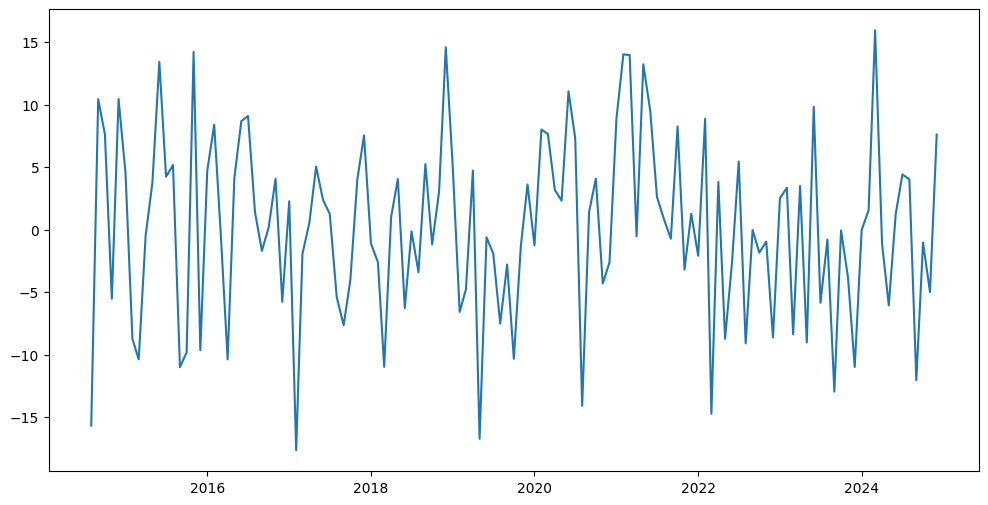

In [83]:
fig = plt.figure(figsize=(12, 6))
plt.plot(model_p1.resid()[2:],label="Residuales")

In [84]:
from statsmodels.tsa.arima.model import ARIMA

In [85]:
def evaluar_expanding_forecast_arima(
      serie,
      order,
      window=windows_size,
      step_size=step_size,
      horizon=horizon_size,
      metric='rmse',
      mobile_windows: bool = False,
    ):
    """
    Simula pronósticos autoregresivos en tiempo real con ventana expandida desde el inicio.

    Parámetros:
        serie     : serie temporal (pd.Series o array-like)
        order     : tupla ARIMA (p,d,q)
        window    : cantidad de pronósticos (desde el final hacia atrás)
        step_size : cada cuántos puntos se hace un pronóstico
        horizon   : cuántos pasos adelante predices en cada punto
        metric    : 'rmse' o 'mae'

    Retorna:
        Error promedio global (RMSE o MAE) entre todos los valores predichos vs observados.
    """

    # Asegurar tipo y limpiar NaN de la serie
    serie = pd.Series(serie).astype(float).dropna()

    n = len(serie)
    predichos = []
    observados = []

    # índices donde termina el conjunto de entrenamiento
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))

    for end_train in puntos_finales:
        train = serie.iloc[end_train + window - n:end_train] if mobile_windows else serie.iloc[:end_train]
        test = serie.iloc[end_train:end_train + horizon]

        if len(test) < horizon:
            continue

        # Si el test ya tiene NaN, lo ignoramos
        if test.isna().any():
            continue

        try:
            model = ARIMA(
                train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()

            pred = model.forecast(steps=horizon)

        except Exception:
            # Si falla el ajuste o el forecast, pasamos a la siguiente ventana
            continue

        # Convertir a Series y filtrar NaN en predicciones
        pred = pd.Series(pred).astype(float)

        # Máscara conjunta para asegurar que ni observados ni predichos tengan NaN
        mask = (~pred.isna()) & (~test.isna())

        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask].tolist())
        observados.extend(test[mask].tolist())

    if len(predichos) == 0:
        return np.inf

    predichos = np.array(predichos, dtype=float)
    observados = np.array(observados, dtype=float)

    mask_finite = (
        np.isfinite(predichos) &
        np.isfinite(observados)
    )

    if mask_finite.sum() == 0:
        return np.inf

    predichos = predichos[mask_finite]
    observados = observados[mask_finite]

    # Cálculo de la métrica
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    elif metric == 'mae':
        return np.mean(np.abs(observados - predichos))
    else:
        raise ValueError("Metric must be 'rmse' or 'mae'")


In [86]:
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [87]:
df['producto1']

,producto1
Date,
2014-06-01,500.000000
2014-07-01,497.400893
2014-08-01,478.605317
2014-09-01,486.454125
2014-10-01,479.695678
...,...
2024-08-01,164.610771
2024-09-01,150.881839
2024-10-01,151.788470


In [88]:
windows_size

60

In [89]:
trials_size

20

In [90]:
def objective(trial, serie, mobile_windows):

    p = trial.suggest_int("p", 1, 10)
    d = trial.suggest_int("d", 1, 2)
    q = trial.suggest_int("q", 1, 10)

    order = (p, d, q)
    # Pass mobile_windows to evaluar_expanding_forecast_arima
    return evaluar_expanding_forecast_arima(serie, order,mobile_windows=mobile_windows)


**producto1**

In [91]:
study_arima_mobile = optuna.create_study(direction="minimize")
# Pass mobile_windows=True to the objective function via the lambda
study_arima_mobile.optimize(lambda trial: objective(trial, serie=df['producto1'], mobile_windows=True), n_trials=trials_size, n_jobs=-1)

plot_ets_rmse_from_study(
    study_arima_mobile,
    'Modelo ARIMA - ventana movil producto1'
)

[I 2025-12-07 00:21:37,165] A new study created in memory with name: no-name-1f70c402-d7d5-42bb-b116-a81cf218fdf1
[I 2025-12-07 00:22:28,686] Trial 1 finished with value: 8.139438633022385 and parameters: {'p': 3, 'd': 2, 'q': 5}. Best is trial 1 with value: 8.139438633022385.
[I 2025-12-07 00:22:55,808] Trial 0 finished with value: 177026.75603332464 and parameters: {'p': 8, 'd': 2, 'q': 4}. Best is trial 1 with value: 8.139438633022385.
[I 2025-12-07 00:23:55,656] Trial 3 finished with value: 8.219364262465062 and parameters: {'p': 5, 'd': 2, 'q': 5}. Best is trial 1 with value: 8.139438633022385.
[I 2025-12-07 00:24:05,427] Trial 2 finished with value: 7.730931223957459 and parameters: {'p': 5, 'd': 1, 'q': 10}. Best is trial 2 with value: 7.730931223957459.
[I 2025-12-07 00:25:35,604] Trial 5 finished with value: 7.800114521967811 and parameters: {'p': 4, 'd': 2, 'q': 9}. Best is trial 2 with value: 7.730931223957459.
[I 2025-12-07 00:25:46,176] Trial 4 finished with value: 7.50430

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 7.5043
  Proceso -> Modelo ARIMA - ventana movil producto1:
    p: 7
    d: 1
    q: 10


In [92]:
study_arima_recursive = optuna.create_study(direction="minimize")
# Pass mobile_windows=True to the objective function via the lambda
study_arima_recursive.optimize(lambda trial: objective(trial, serie=df['producto1'], mobile_windows=False), n_trials=trials_size, n_jobs=-1)

plot_ets_rmse_from_study(
    study_arima_recursive,
    'Modelo ARIMA - ventana recursiva producto1'
)

[I 2025-12-07 00:36:53,238] A new study created in memory with name: no-name-621a13bf-f046-4974-a323-3a725593795c
[I 2025-12-07 00:37:02,684] Trial 1 finished with value: 7.729242115045385 and parameters: {'p': 2, 'd': 2, 'q': 1}. Best is trial 1 with value: 7.729242115045385.
[I 2025-12-07 00:37:03,673] Trial 0 finished with value: 7.435669701319071 and parameters: {'p': 2, 'd': 1, 'q': 2}. Best is trial 0 with value: 7.435669701319071.
[I 2025-12-07 00:37:39,783] Trial 3 finished with value: 7.900473453807905 and parameters: {'p': 2, 'd': 2, 'q': 4}. Best is trial 0 with value: 7.435669701319071.
[I 2025-12-07 00:38:28,566] Trial 2 finished with value: 7.663586077521094 and parameters: {'p': 10, 'd': 2, 'q': 2}. Best is trial 0 with value: 7.435669701319071.
[I 2025-12-07 00:40:15,245] Trial 5 finished with value: 8.070490353432143 and parameters: {'p': 3, 'd': 1, 'q': 9}. Best is trial 0 with value: 7.435669701319071.
[I 2025-12-07 00:40:16,715] Trial 4 finished with value: 8.157041

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 7.4357
  Proceso -> Modelo ARIMA - ventana recursiva producto1:
    p: 2
    d: 1
    q: 2


**producto2**

In [93]:
study_arima_mobile = optuna.create_study(direction="minimize")
# Pass mobile_windows=True to the objective function via the lambda
study_arima_mobile.optimize(lambda trial: objective(trial, serie=df['producto2'], mobile_windows=True), n_trials=trials_size, n_jobs=-1)

plot_ets_rmse_from_study(
    study_arima_mobile,
    'Modelo ARIMA - ventana movil producto2'
)

[I 2025-12-07 00:48:31,564] A new study created in memory with name: no-name-1987e02e-5c06-4c0c-8458-17b83840e56e
[I 2025-12-07 00:48:53,837] Trial 1 finished with value: 10.01373906403412 and parameters: {'p': 3, 'd': 2, 'q': 1}. Best is trial 1 with value: 10.01373906403412.
[I 2025-12-07 00:49:24,965] Trial 0 finished with value: 10.432733945880159 and parameters: {'p': 5, 'd': 1, 'q': 3}. Best is trial 1 with value: 10.01373906403412.
[I 2025-12-07 00:50:25,474] Trial 2 finished with value: 11.518662995666281 and parameters: {'p': 10, 'd': 2, 'q': 3}. Best is trial 1 with value: 10.01373906403412.
[I 2025-12-07 00:50:40,092] Trial 3 finished with value: 10.488726553984304 and parameters: {'p': 2, 'd': 1, 'q': 9}. Best is trial 1 with value: 10.01373906403412.
[I 2025-12-07 00:51:52,312] Trial 4 finished with value: 10.740673781297225 and parameters: {'p': 5, 'd': 1, 'q': 8}. Best is trial 1 with value: 10.01373906403412.
[I 2025-12-07 00:52:14,525] Trial 6 finished with value: 10.2

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 9.9193
  Proceso -> Modelo ARIMA - ventana movil producto2:
    p: 4
    d: 1
    q: 5


In [94]:
study_arima_recursive = optuna.create_study(direction="minimize")
# Pass mobile_windows=True to the objective function via the lambda
study_arima_recursive.optimize(lambda trial: objective(trial, serie=df['producto2'], mobile_windows=False), n_trials=trials_size, n_jobs=-1)

plot_ets_rmse_from_study(
    study_arima_recursive,
    'Modelo ARIMA - ventana recursiva producto2'
)

[I 2025-12-07 00:58:18,737] A new study created in memory with name: no-name-44f02095-0946-4206-82de-6cd802dd1398
[I 2025-12-07 01:00:04,420] Trial 1 finished with value: 10.811408831587206 and parameters: {'p': 10, 'd': 1, 'q': 2}. Best is trial 1 with value: 10.811408831587206.
[I 2025-12-07 01:00:16,139] Trial 0 finished with value: 11.692963398501822 and parameters: {'p': 9, 'd': 2, 'q': 4}. Best is trial 1 with value: 10.811408831587206.
[I 2025-12-07 01:02:02,019] Trial 3 finished with value: 10.82591383389933 and parameters: {'p': 7, 'd': 2, 'q': 6}. Best is trial 1 with value: 10.811408831587206.
[I 2025-12-07 01:02:32,595] Trial 2 finished with value: 11.045610536253657 and parameters: {'p': 8, 'd': 1, 'q': 9}. Best is trial 1 with value: 10.811408831587206.
[I 2025-12-07 01:03:23,231] Trial 5 finished with value: 10.948332749072202 and parameters: {'p': 3, 'd': 2, 'q': 2}. Best is trial 1 with value: 10.811408831587206.
[I 2025-12-07 01:04:29,482] Trial 6 finished with value:

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 10.1883
  Proceso -> Modelo ARIMA - ventana recursiva producto2:
    p: 1
    d: 1
    q: 7


In [95]:
view_score_rmse()

,Producto,Ventana,RMSE,Modelo,Parametros
23,producto1,Movil,7.504303,Modelo ARIMA - ventana movil producto1,"{'p': 7, 'd': 1, 'q': 10}"
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
12,producto1,Movil,30.554400,Tendencia lienal - ventana movil producto1,{'grado': 4}
8,producto1,Movil,57.704224,Tendencia lienal - ventana movil producto1,{}
19,producto1,Movil,66.756503,Tendencia lineal polinomica que incorpore esta...,{'grado': 4}
15,producto1,Movil,75.757800,Tendencia lineal que incorpore estacionalidad ...,{}
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
24,producto1,Recusiva,7.435670,Modelo ARIMA - ventana recursiva producto1,"{'p': 2, 'd': 1, 'q': 2}"
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."
13,producto1,Recusiva,40.398241,Tendencia lienal - ventana recursiva producto1,{'grado': 4}


**Modelos para series de tiempo multiestacionales, puntos de cambio y festividades (Prophet)**

In [96]:
df_prophet = df.copy()
df_prophet

,producto1,producto2
Date,,
2014-06-01,500.000000,200.000000
2014-07-01,497.400893,210.686220
2014-08-01,478.605317,222.018584
2014-09-01,486.454125,233.920990
2014-10-01,479.695678,238.402098
...,...,...
2024-08-01,164.610771,629.293034
2024-09-01,150.881839,637.099467
2024-10-01,151.788470,653.155282


2015-08-01 00:00:00
2016-11-01 00:00:00
2018-02-01 00:00:00
2019-05-01 00:00:00
2021-11-01 00:00:00
2023-07-01 00:00:00
2024-12-01 00:00:00


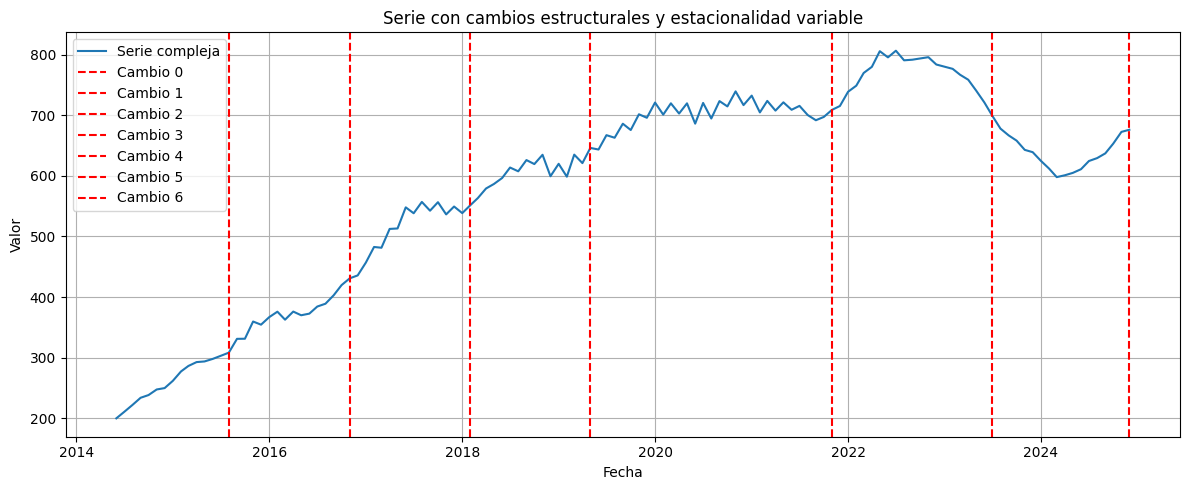

In [97]:
plt.figure(figsize=(12, 5))
plt.plot(df['producto2'], label="Serie compleja")
for idx, c in enumerate(rpt.Pelt(model="rbf").fit(df['producto2'].values).predict(pen=3)):
    print(df.index[c-1])
    plt.axvline(df.index[c-1], color='red', linestyle='--', label=f"Cambio {idx}")
plt.title("Serie con cambios estructurales y estacionalidad variable")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

2017-09-01 00:00:00
2019-05-01 00:00:00
2021-06-01 00:00:00
2023-02-01 00:00:00
2023-12-01 00:00:00
2024-12-01 00:00:00


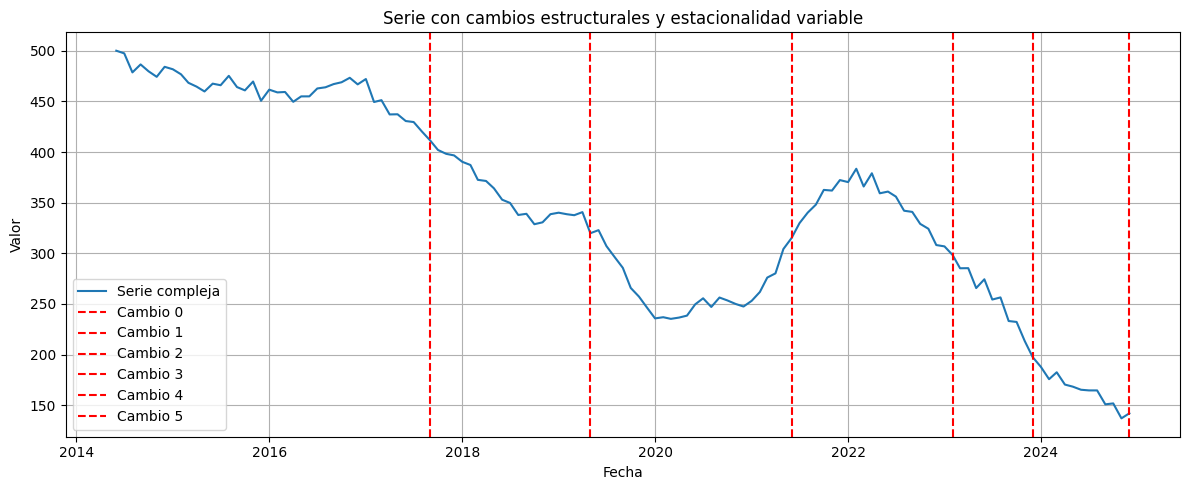

In [98]:
plt.figure(figsize=(12, 5))
plt.plot(df['producto1'], label="Serie compleja")
for idx, c in enumerate(rpt.Pelt(model="rbf").fit(df['producto1'].values).predict(pen=3)):
    print(df.index[c-1])
    plt.axvline(df.index[c-1], color='red', linestyle='--', label=f"Cambio {idx}")
plt.title("Serie con cambios estructurales y estacionalidad variable")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Teniendo en cuenta el análisis  de impacto anteriormente nombrado en el primer análisis  realizado, la serie tiene cambios cada 3 meses donde por lo cual se creara una variable **Mercado** donde se estará realizando la nueva covariable.





In [99]:
df_prophet['mes'] = df_prophet.index.month
df_prophet

,producto1,producto2,mes
Date,,,
2014-06-01,500.000000,200.000000,6
2014-07-01,497.400893,210.686220,7
2014-08-01,478.605317,222.018584,8
2014-09-01,486.454125,233.920990,9
2014-10-01,479.695678,238.402098,10
...,...,...,...
2024-08-01,164.610771,629.293034,8
2024-09-01,150.881839,637.099467,9
2024-10-01,151.788470,653.155282,10


In [100]:
df_prophet['Mercado'] = df_prophet['mes'].isin([3, 6, 9, 12]).astype(int)
df_prophet

,producto1,producto2,mes,Mercado
Date,,,,
2014-06-01,500.000000,200.000000,6,1
2014-07-01,497.400893,210.686220,7,0
2014-08-01,478.605317,222.018584,8,0
2014-09-01,486.454125,233.920990,9,1
2014-10-01,479.695678,238.402098,10,0
...,...,...,...,...
2024-08-01,164.610771,629.293034,8,0
2024-09-01,150.881839,637.099467,9,1
2024-10-01,151.788470,653.155282,10,0


In [101]:
df_prophet.rename_axis('ds', inplace=True)
df_prophet['ds'] = df_prophet.index
df_prophet

,producto1,producto2,mes,Mercado,ds
ds,,,,,
2014-06-01,500.000000,200.000000,6,1,2014-06-01
2014-07-01,497.400893,210.686220,7,0,2014-07-01
2014-08-01,478.605317,222.018584,8,0,2014-08-01
2014-09-01,486.454125,233.920990,9,1,2014-09-01
2014-10-01,479.695678,238.402098,10,0,2014-10-01
...,...,...,...,...,...
2024-08-01,164.610771,629.293034,8,0,2024-08-01
2024-09-01,150.881839,637.099467,9,1,2024-09-01
2024-10-01,151.788470,653.155282,10,0,2024-10-01


In [102]:
def create_holiday_df(name, df_prophet, lower, upper):
    dates = df_prophet[df_prophet[name] == 1]['ds']
    return pd.DataFrame({
        'holiday': name.replace(" ", "."),
        'ds': dates,
        'lower_window': lower,
        'upper_window': upper
    })
holidays = create_holiday_df('Mercado', df_prophet, 0, 0)
holidays
# holidays = pd.concat([christmas, black_friday, easter], ignore_index=True)

,holiday,ds,lower_window,upper_window
ds,,,,
2014-06-01,Mercado,2014-06-01,0,0
2014-09-01,Mercado,2014-09-01,0,0
2014-12-01,Mercado,2014-12-01,0,0
2015-03-01,Mercado,2015-03-01,0,0
2015-06-01,Mercado,2015-06-01,0,0
2015-09-01,Mercado,2015-09-01,0,0
2015-12-01,Mercado,2015-12-01,0,0
2016-03-01,Mercado,2016-03-01,0,0
2016-06-01,Mercado,2016-06-01,0,0


In [103]:
df_prophet_p1 = df.reset_index().rename(columns={'Date': 'ds', 'producto1': 'y'})[['ds', 'y']]
df_prophet_p1

,ds,y
0,2014-06-01,500.000000
1,2014-07-01,497.400893
2,2014-08-01,478.605317
3,2014-09-01,486.454125
4,2014-10-01,479.695678
...,...,...
122,2024-08-01,164.610771
123,2024-09-01,150.881839
124,2024-10-01,151.788470
125,2024-11-01,137.047639


In [104]:
df_prophet_p2 = df.reset_index().rename(columns={'Date': 'ds', 'producto2': 'y'})[['ds', 'y']]
df_prophet_p2

,ds,y
0,2014-06-01,200.000000
1,2014-07-01,210.686220
2,2014-08-01,222.018584
3,2014-09-01,233.920990
4,2014-10-01,238.402098
...,...,...
122,2024-08-01,629.293034
123,2024-09-01,637.099467
124,2024-10-01,653.155282
125,2024-11-01,672.528345


In [105]:
from prophet import Prophet


In [106]:
def rolling_forecast_eval_prophet(data, params, holidays=None,
                          initial_train_size=windows_size,
                          forecast_horizon=horizon_size,
                          step_size=step_size,
                          regressors=None,
                          mobile_windows=True
                          ):

    # Aseguramos que regressors sea una lista si no se pasa nada
    if regressors is None:
        regressors = []

    data = data.sort_values('ds').reset_index(drop=True)
    n = len(data)
    metrics = []

    for start in range(0, n - initial_train_size - forecast_horizon + 1, step_size):
        train = data.iloc[start:start + initial_train_size] if mobile_windows else data.iloc[:start + initial_train_size]
        test = data.iloc[start + initial_train_size:start + initial_train_size + forecast_horizon]

        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            holidays=holidays,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            holidays_prior_scale=params['holidays_prior_scale'],
            seasonality_mode=params['seasonality_mode'],
            n_changepoints=params['n_changepoints']
        )

        model.add_seasonality(name='trimestral', period=91.25, fourier_order=5)
        for reg in regressors:
            model.add_regressor(reg)

        model.fit(train)

        forecast = model.predict(test[['ds']])

        y_true = test['y'].values
        y_pred = forecast['yhat'].values

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = np.mean(np.abs(y_true - y_pred))

        metrics.append({
            'window_start': train['ds'].iloc[0],
            'window_end': train['ds'].iloc[-1],
            'rmse': rmse,
            'mae': mae,
        })

    return pd.DataFrame(metrics)

In [107]:
def objective(trial, df_p, mobile_windows):
    params = {
        'changepoint_prior_scale': trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float("seasonality_prior_scale", 0.01, 10, log=True),
        'holidays_prior_scale': trial.suggest_float("holidays_prior_scale", 0.01, 10, log=True),
        'seasonality_mode': trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        'n_changepoints': trial.suggest_int("n_changepoints", 1, 20)
    }
    results_df = rolling_forecast_eval_prophet(
        df_p,
        params,
        holidays=holidays,
        # regressors=['Mercado'],
        mobile_windows=mobile_windows
        )
    rmse_mean = results_df['rmse'].mean()
    trial.set_user_attr("rmse_by_window", results_df['rmse'].tolist())
    return rmse_mean

**producto1**

In [108]:
study_prophet_p1 = optuna.create_study(direction="minimize")
# Corrected: Use a lambda function to pass df_p to the objective
study_prophet_p1.optimize(lambda trial: objective(trial, df_p=df_prophet_p1, mobile_windows=True), n_trials=trials_size, n_jobs=-1)

[I 2025-12-07 01:10:44,357] A new study created in memory with name: no-name-c7a6ae85-bbd0-48ff-ab69-89f23168cbdc
[I 2025-12-07 01:11:20,050] Trial 0 finished with value: 72.35358269677577 and parameters: {'changepoint_prior_scale': 0.007484936353039763, 'seasonality_prior_scale': 0.05724164508601897, 'holidays_prior_scale': 2.0350030576070437, 'seasonality_mode': 'additive', 'n_changepoints': 7}. Best is trial 0 with value: 72.35358269677577.
[I 2025-12-07 01:11:21,234] Trial 1 finished with value: 71.75066141675937 and parameters: {'changepoint_prior_scale': 0.0018598189175312858, 'seasonality_prior_scale': 0.029515684056137876, 'holidays_prior_scale': 0.4448556076060814, 'seasonality_mode': 'additive', 'n_changepoints': 14}. Best is trial 1 with value: 71.75066141675937.
[I 2025-12-07 01:11:38,833] Trial 3 finished with value: 69.59964614095504 and parameters: {'changepoint_prior_scale': 0.006775032892983203, 'seasonality_prior_scale': 0.12987119920484894, 'holidays_prior_scale': 4.

In [109]:
plot_ets_rmse_from_study(
    study_prophet_p1,
    'Modelo PROPHET - ventana movil producto1'
)

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 11.1792
  Proceso -> Modelo PROPHET - ventana movil producto1:
    changepoint_prior_scale: 0.3564315450105214
    seasonality_prior_scale: 0.4077747668816192
    holidays_prior_scale: 6.460895567280843
    seasonality_mode: multiplicative
    n_changepoints: 16


In [110]:
study_prophet_p1_r = optuna.create_study(direction="minimize")
# Corrected: Use a lambda function to pass df_p to the objective
study_prophet_p1_r.optimize(lambda trial: objective(trial, df_p=df_prophet_p1, mobile_windows=False), n_trials=trials_size, n_jobs=-1)

[I 2025-12-07 01:24:21,995] A new study created in memory with name: no-name-ce03480a-0700-40e9-8f40-e027096c4271
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
[I 2025-12-07 01:24:43,276] Trial 0 finished with value: 40.90656793682681 and parameters: {'changepoint_prior_scale': 0.13718169996285393, 'seasonality_prior_scale': 0.10907230613772817, 'holidays_prior_scale': 1.6209645535896102, 'seasonality_mode': 'additive', 'n_changepoints': 4}. Best is trial 0 with value: 40.90656793682681.
[I 2025-12-07 01:24:57,415] Trial 1 finished with value: 55.313522948221376 and parameters: {'changepoint_prior_scale': 0.017740224354085905, 'seasonality_prior_scale': 0.29634746927425315, 'holidays_prior_scale': 0.017363195324245538, 'seasonality_mode': 'multiplicative', 'n_changepoints

In [111]:
plot_ets_rmse_from_study(
    study_prophet_p1_r,
    'Modelo PROPHET - ventana recursiva producto1'
)

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 31.0126
  Proceso -> Modelo PROPHET - ventana recursiva producto1:
    changepoint_prior_scale: 0.1162462323314613
    seasonality_prior_scale: 1.1516835853884442
    holidays_prior_scale: 6.689530048166969
    seasonality_mode: multiplicative
    n_changepoints: 20


In [112]:
study_prophet_p2 = optuna.create_study(direction="minimize")
# Corrected: Use a lambda function to pass df_p to the objective
study_prophet_p2.optimize(lambda trial: objective(trial, df_p=df_prophet_p2, mobile_windows=True), n_trials=trials_size, n_jobs=-1)

[I 2025-12-07 01:35:00,911] A new study created in memory with name: no-name-b0ddccd6-3db1-4ca7-8938-e20eb4a4fc91
[I 2025-12-07 01:35:36,815] Trial 0 finished with value: 58.91010496036715 and parameters: {'changepoint_prior_scale': 0.001683823970295215, 'seasonality_prior_scale': 0.3497065419262204, 'holidays_prior_scale': 9.368630914210582, 'seasonality_mode': 'additive', 'n_changepoints': 14}. Best is trial 0 with value: 58.91010496036715.
[I 2025-12-07 01:36:22,526] Trial 2 finished with value: 30.56902424772791 and parameters: {'changepoint_prior_scale': 0.344095293829437, 'seasonality_prior_scale': 2.276265317271807, 'holidays_prior_scale': 0.21782894641554204, 'seasonality_mode': 'multiplicative', 'n_changepoints': 10}. Best is trial 2 with value: 30.56902424772791.
[I 2025-12-07 01:36:45,811] Trial 1 finished with value: 23.074534631292966 and parameters: {'changepoint_prior_scale': 0.43275996585993376, 'seasonality_prior_scale': 0.4971966180062982, 'holidays_prior_scale': 0.47

In [113]:
plot_ets_rmse_from_study(
    study_prophet_p2,
    'Modelo PROPHET - ventana movil producto2'
)

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 23.0745
  Proceso -> Modelo PROPHET - ventana movil producto2:
    changepoint_prior_scale: 0.43275996585993376
    seasonality_prior_scale: 0.4971966180062982
    holidays_prior_scale: 0.4702933010673199
    seasonality_mode: multiplicative
    n_changepoints: 20


In [114]:
study_prophet_p2_r = optuna.create_study(direction="minimize")
# Corrected: Use a lambda function to pass df_p to the objective
study_prophet_p2_r.optimize(lambda trial: objective(trial, df_p=df_prophet_p2, mobile_windows=False), n_trials=trials_size, n_jobs=-1)

[I 2025-12-07 01:44:35,265] A new study created in memory with name: no-name-a88cb716-d75c-47d4-8fb5-1857232a9685
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
[I 2025-12-07 01:45:01,314] Trial 0 finished with value: 46.541415129506554 and parameters: {'changepoint_prior_scale': 0.02768576937387392, 'seasonality_prior_scale': 3.9049584479703294, 'holidays_prior_scale': 0.018991881413624068, 'seasonality_mode': 'additive', 'n_changepoints': 6}. Best is trial 0 with value: 46.541415129506554.
[I 2025-12-07 01:45:27,439] Trial 1 finished with value: 45.16088383099102 and parameters: {'changepoint_prior_scale': 0.18566304420809684, 'seasonality_prior_scale': 0.2505735386487573, 'holidays_prior_scale': 0.49344084819465733, 'seasonality_mode': 'multiplicative', 'n_changepoints'

In [115]:
plot_ets_rmse_from_study(
    study_prophet_p2_r,
    'Modelo PROPHET - ventana recursiva producto2'
)

Mejor ensayo (modelo) encontrado con optimización bayesiana es:
  Valor (RMSE): 36.9774
  Proceso -> Modelo PROPHET - ventana recursiva producto2:
    changepoint_prior_scale: 0.06006068858389759
    seasonality_prior_scale: 0.01108587116413668
    holidays_prior_scale: 1.869843863852381
    seasonality_mode: additive
    n_changepoints: 1


In [116]:
df_score_end = view_score_rmse()
df_score_end

,Producto,Ventana,RMSE,Modelo,Parametros
23,producto1,Movil,7.504303,Modelo ARIMA - ventana movil producto1,"{'p': 7, 'd': 1, 'q': 10}"
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
27,producto1,Movil,11.179243,Modelo PROPHET - ventana movil producto1,{'changepoint_prior_scale': 0.3564315450105214...
12,producto1,Movil,30.554400,Tendencia lienal - ventana movil producto1,{'grado': 4}
8,producto1,Movil,57.704224,Tendencia lienal - ventana movil producto1,{}
19,producto1,Movil,66.756503,Tendencia lineal polinomica que incorpore esta...,{'grado': 4}
15,producto1,Movil,75.757800,Tendencia lineal que incorpore estacionalidad ...,{}
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
24,producto1,Recusiva,7.435670,Modelo ARIMA - ventana recursiva producto1,"{'p': 2, 'd': 1, 'q': 2}"
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."


In [117]:
df_score_end.to_csv('df_score_end.csv', index=False)

In [118]:
df_score_end.shape

(31, 5)

In [119]:
# Imprimir los dos mejores modelos encontrados
modelo = {}
for row in df_score_end.iterrows():
    product = row[1]['Producto']
    if product not in modelo:
      modelo[product] = 1
    else:
      modelo[product] += 1

    if modelo[product] < 3:
      print(row[1]['Modelo'], ' -> ', row[1]['Parametros'])


Modelo ARIMA - ventana movil producto1  ->  {'p': 7, 'd': 1, 'q': 10}
ESTModel holt - ventana movil producto1  ->  {'error': 'add', 'trend': 'mul', 'seasonal': None, 'aplha': 0.5408940203078912, 'beta': 0.7292205569221633, 'gamma': 0.39662407398263877}
Modelo ARIMA - ventana movil producto2  ->  {'p': 4, 'd': 1, 'q': 5}
ESTModel holt - ventana movil producto2  ->  {'error': 'add', 'trend': 'add', 'seasonal': 'add', 'aplha': 0.9631842583367579, 'beta': 0.7927585618141351, 'gamma': 0.05496978790136353}


Teniendo en cuenta todos los entreamiento de lo modelos desde un **promedio movil** hasta llegar a los modelos de **prophet**, estos dos modelos fueron entrenado bajo dos metodos para la generacion de pronosticos (**ventana movil** y **ventana recursiva**), entre los dos productos estrella se evaluaron 31 formas y donde se conluye.

* El mejor modelo teniendo en cuenta la optimizacion bayesiana para **producto1** es **Modelo ARIMA - ventana movil producto1** obteniendo un RMSE de **7.50** y para el **producto2** es **Modelo ARIMA - ventana movil producto2** con un RMSE de **9.92**.
* Tambien debemos de tener en cuenta al segundo mejor modelo ya que es un modelo que nos ayuda a tener una mejor interpretabilidad donde el **producto1** es **ESTModel holt - ventana movil producto1** teniendo como referencia a **Holt multiplicativo sin componente estacional** obteniendo un RMSE de **8.25** y para el **producto2** es **ESTModel holt - ventana movil producto2** teniendo como referencia a **Holt-Winters aditivo** con un RMSE de **14.48**.
* Este conjunto de datos lo que nos indica la **optimizacion bayesiana** nos indica que el mejor metodo de entrenar el modelo es por **ventana movil**.
* **ARIMA** captura patrones complejos y proporciona la mejor precisión predictiva; sin embargo, **ESTModel holt** es valioso para análisis estructurales porque representa mejor la descomposición de la serie y facilita decisiones informadas más allá del pronóstico inmediato.

Teniendo en cuenta estas conclusiones se decide validar los **supuestos** del modelo **ARIMA** si cumplen o si no se cumple poder obtar por **ESTModel holt**.

**Modelo ARIMA**

In [120]:
from pmdarima.arima import ARIMA

In [121]:
model_arima_fp1 = ARIMA(order=(8,1,10))
results_arima_fp1 = model_arima_fp1.fit(df["producto1"])

In [122]:
results_arima_fp1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  127
Model:              SARIMAX(8, 1, 10)   Log Likelihood                -413.870
Date:                Sun, 07 Dec 2025   AIC                            867.740
Time:                        01:50:04   BIC                            924.466
Sample:                    06-01-2014   HQIC                           890.786
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.3442      0.431     -0.798      0.425      -1.189       0.501
ar.L1         -0.1845      0.251     -0.734      0.463      -0.677       0.308
ar.L2          0.2082      0.244      0.854      0.393      -0.269       0.686
ar.L3          0.4770      0.244      1.951      0.051      -0.002       0.956
ar.L4          0.7601      0.295      2.575      0.010       0.182       1.339
ar.L5          0.3731      0.222      1.678      0.093      -0.063       0.809
ar.L6         -0.1420      0.196     -0.725      0.469      -0.526       0.242
ar.L7       1.215e-05      0.195   6.23e-05      1.000      -0.383       0.383
ar.L8         -0.6260      0.187     -3.342      0.001      -0.993      -0.259
ma.L1          0.0749      1.431      0.052      0.958      -2.729       2.879
ma.L2          0.4179      3.324      0.126      0.900      -6.098       6.934
ma.L3         -0.1886      2.926     -0.064      0.949      -5.924       5.546
ma.L4         -0.5640      0.627     -0.900      0.368      -1.792       0.664
ma.L5         -0.5852      2.982     -0.196      0.844      -6.430       5.260
ma.L6         -0.4436      3.244     -0.137      0.891      -6.803       5.915
ma.L7         -0.3691      1.270     -0.291      0.771      -2.858       2.119
ma.L8          0.6409      1.736      0.369      0.712      -2.763       4.044
ma.L9         -0.2254      0.840     -0.268      0.788      -1.871       1.420
ma.L10         0.2580      1.113      0.232      0.817      -1.924       2.440
sigma2        33.5959    141.983      0.237      0.813    -244.685     311.877
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 3.13
Prob(Q):                              0.88   Prob(JB):                         0.21
Heteroskedasticity (H):               0.70   Skew:                            -0.37
Prob(H) (two-sided):                  0.25   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

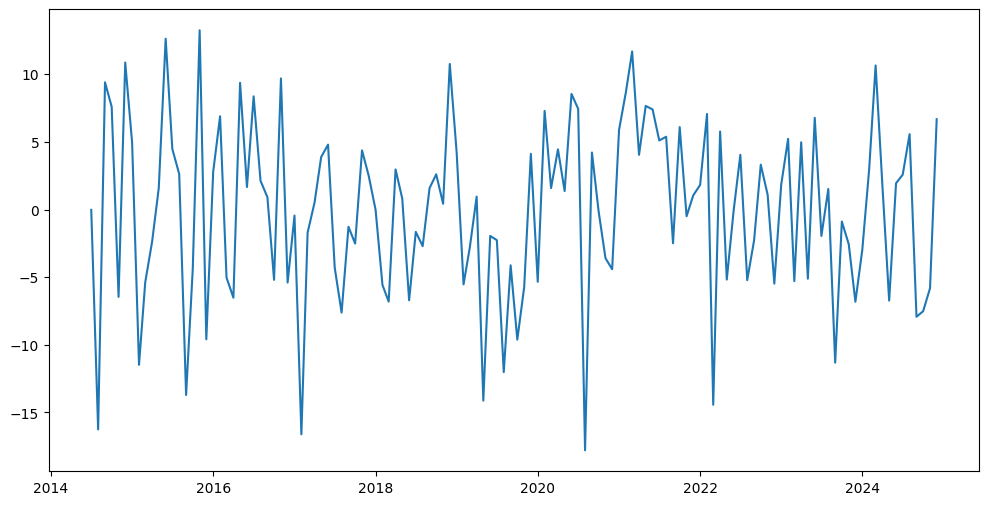

In [123]:
fig = plt.figure(figsize=(12, 6))
plt.plot(results_arima_fp1.resid()[1:],label="Residuales")

**correlacion Autocorrelación**

Para determinar si existe autocorrelación vamos a usar la prueba de rachas propuesta por Wald y Wolfowitz, 1940. Es una prueba no paramétrica donde las hipótesis son las siguientes:

$H{0}: ρ = 0$ (Es decir no hay autocorrelación)

$H{1}: ρ \not= 0$ (Es decir hay autocorrelación)

Rechazo $H{0}$ cuando el p-valor es menor al nivel de significancia, convencionalmente se usa un $α$=0.05 ($α$ = nivel de significancia).

**Homoscedasticidad y Heteroscedasticidad**

Ahora nos queda por chequear si existe problemas de heteroscedasticidad, en
especial un comportamiento tipo ARCH o GARCH, esto implica que la varianza de la serie tenga un comportamiento no autocorrelacionado.

Una aproximación para determinar si existe un comportamiento GARCH o
ARCH es emplear la prueba de Ljung-Box sobre la serie (sin media) al cuadrado.

$H{0}:$ Comportamiento Homoscedastico (Es decir varianza constante)

$H{1}:$ Comportamiento Heteroscedastico (Es decir varianza no constante)

**Normalidad**

Finalmente, podemos evaluar si la serie sigue una distribución normal o no. Noten que esto no es necesario para ser ruido blanco, solo para ser ruido blanco gaussiano. Primero hagamos un análisis gráfico empleando las siguientes lineas de código.

In [124]:
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy import stats

In [125]:
def val_supuestos(result_arima_):
  """
    Valida los principales supuestos del modelo ARIMA utilizando los residuos del ajuste.

    Se evalúan:
      1. Autocorrelación de residuos (Ljung-Box, Box-Pierce y prueba runs test)
      2. Homocedasticidad
      3. Normalidad (QQ-plot, histograma, Shapiro-Wilk, Jarque-Bera)

    Args:
        result_arima_ (statsmodels ARIMAResults):
            Resultado del modelo ARIMA ajustado, incluyendo residuos.

    Returns:
        None
            La función imprime los resultados de las pruebas y grafica la distribución.
  """
  print("======== VALIDACIÓN DE SUPUESTOS ARIMA ========")

  print("----------------------------------------------")
  print("\n1. Supuesto de Autocorrelación")
  signo_arima_ = result_arima_.resid()>0

  print("\nRuns Test (aleatoriedad del signo del residuo):")
  s_at = runstest_1samp(signo_arima_, correction=False)
  print(s_at)

  print("\nLjung-Box y Box-Pierce (lag=1):")
  print(sm.stats.acorr_ljungbox(result_arima_.resid(), lags=[1], return_df=True,boxpierce=True ))

  # Ljung-Box y Box-Pierce para múltiples lags
  Resul_lb_bp_arima_ = sm.stats.acorr_ljungbox(result_arima_.resid(), lags=range(1,126), return_df=True,boxpierce=True )
  Resul_lb_bp_arima_["lb_ho"] = np.where(Resul_lb_bp_arima_['lb_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')
  Resul_lb_bp_arima_["bp_ho"] = np.where(Resul_lb_bp_arima_['bp_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')
  print("\nResultados completos Ljung-Box / Box-Pierce:")
  print(Resul_lb_bp_arima_)

  print("----------------------------------------------")
  print("\n\n2. Supuesto de Homocedasticidad")
  print("\nLjung-Box sobre residuos al cuadrado:")
  print(sm.stats.acorr_ljungbox((result_arima_.resid() - result_arima_.resid().mean())**2, lags=range(1,126), return_df=True,boxpierce=True ))

  print("----------------------------------------------")
  print("\n\n3. Supuesto de Normalidad")
  print("\nQQ-Plot de residuos:")
  sm.qqplot(result_arima_.resid()[1:])
  print()

  # Histograma con distribución normal ajustada

  # Valores de la media (mu) y desviación típica (sigma) de los datos
  mu, sigma = stats.norm.fit(result_arima_.resid()[1:])

  # Valores teóricos de la normal en el rango observado
  x_hat = np.linspace(min(result_arima_.resid()[1:]), max(result_arima_.resid()[1:]), num=100)
  y_hat = stats.norm.pdf(x_hat, mu, sigma)

  # Gráfico
  fig, ax = plt.subplots(figsize=(7,4))
  ax.plot(x_hat, y_hat, linewidth=2, label='normal')
  ax.hist(x=result_arima_.resid()[1:], density=True, bins=30, color="#3182bd", alpha=0.5)
  ax.plot(result_arima_.resid()[1:], np.full_like(result_arima_.resid()[1:], -0.01), '|k', markeredgewidth=1)
  ax.set_title('Distribución Ocupados')
  ax.set_xlabel('Ocupados')
  ax.set_ylabel('Densidad de probabilidad')
  ax.legend();

  # Pruebas formales de normalidad
  print("\nShapiro-Wilk:")
  print(stats.shapiro(result_arima_.resid()))

  print("\nJarque-Bera:")
  print(stats.jarque_bera(result_arima_.resid()))

  print("\n======== FIN VALIDACIÓN SUPUESTOS ARIMA ========\n")



======== VALIDACIÓN DE SUPUESTOS ARIMA ========
----------------------------------------------

1. Supuesto de Autocorrelación

Runs Test (aleatoriedad del signo del residuo):
(np.float64(-1.3059743328029025), np.float64(0.19156128631328917))

Ljung-Box y Box-Pierce (lag=1):
    lb_stat  lb_pvalue   bp_stat  bp_pvalue
1  0.000015   0.996947  0.000014   0.996983

Resultados completos Ljung-Box / Box-Pierce:
       lb_stat  lb_pvalue   bp_stat  bp_pvalue                          lb_ho  \
1     0.000015   0.996947  0.000014   0.996983  no_rechazo_ho/no_hay_autocorr   
2     0.136376   0.934085  0.132148   0.936062  no_rechazo_ho/no_hay_autocorr   
3     0.185481   0.979898  0.179349   0.980852  no_rechazo_ho/no_hay_autocorr   
4     0.211322   0.994796  0.203988   0.995139  no_rechazo_ho/no_hay_autocorr   
5     0.236945   0.998664  0.228221   0.998780  no_rechazo_ho/no_hay_autocorr   
..         ...        ...       ...        ...                            ...   
121   8.266489   1.0000

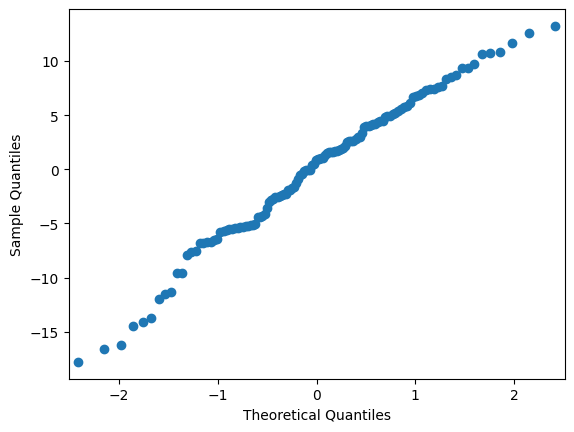

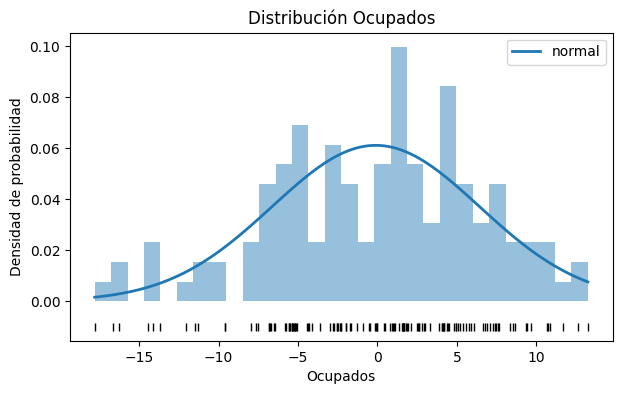

In [126]:
val_supuestos(results_arima_fp1)

Para el **producto1** cumple con **correlacion Autocorrelación** y **Homoscedasticidad y Heteroscedasticidad** teniendo problemas en las pruebas de **Normalidad**.

Este inconveniente puede ser tratado por medio de **boostrap** que nos puede ayudar a generar intervalos de confianza


In [127]:
def bootstrap_forecast(model, data, h=6, B=1000, colname="producto1"):
    """
    Genera pronósticos tipo ARIMA usando bootstrap de residuos.

    model   → modelo ARIMA ya entrenado
    data    → DataFrame original
    h       → horizonte de pronóstico
    B       → número de simulaciones bootstrap
    colname → nombre de la columna Y real
    """

    # Residuales del modelo
    res = model.resid()

    # Bootstrap: B simulaciones de h pasos
    samples = np.random.choice(res, size=(B, h), replace=True)

    # Cuantiles empíricos 95%
    q_low = np.quantile(samples, 0.025, axis=0)
    q_high = np.quantile(samples, 0.975, axis=0)

    # Pronóstico puntual
    fore = model.predict(h, return_conf_int=False)

    # Intervalos acumulados (ARIMA multipaso)
    lower = fore + np.cumsum(q_low)
    upper = fore + np.cumsum(q_high)

    # DataFrame
    preds = pd.DataFrame({
        "Point_forecast": fore,
        "lower_95": lower,
        "upper_95": upper
    }, index=fore.index)

    # --- Gráfica ---
    plt.figure(figsize=(12,5))

    # Serie histórica
    plt.plot(data.index, data[colname], label="Real", color="black")

    # Pronóstico
    plt.plot(preds.index, preds["Point_forecast"], label="Forecast", linestyle="--")

    # Intervalos
    plt.fill_between(preds.index, preds["lower_95"], preds["upper_95"],
                     alpha=0.3, label="95% Bootstrap CI")

    plt.legend()
    plt.title("Pronóstico ARIMA con intervalos Bootstrap")
    plt.show()

    return preds


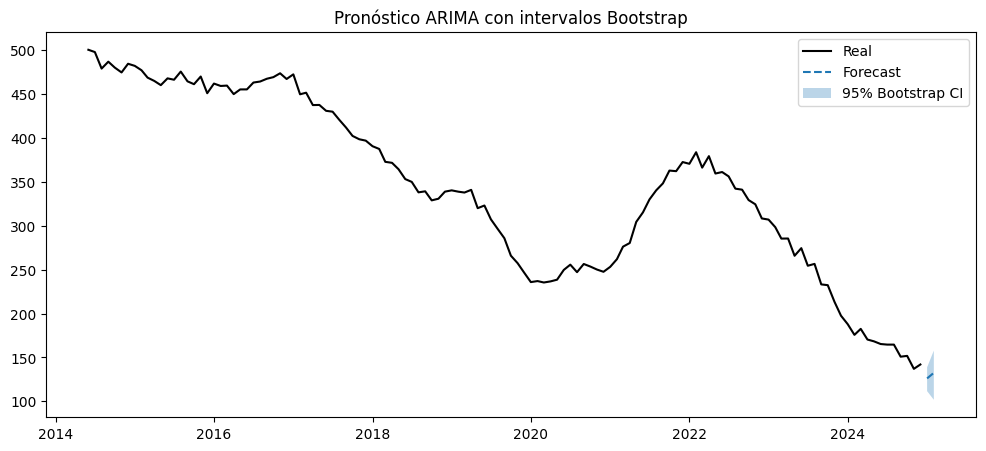

,Point_forecast,lower_95,upper_95
2025-01-01,126.152065,111.717067,138.782516
2025-02-01,132.546541,101.855761,157.807444


In [128]:
preds = bootstrap_forecast(results_arima_fp1, df, h=horizon_size+1, B=1000, colname="producto1")
preds

**producto2**

In [129]:
model_arima_fp2 = ARIMA(order=(2,1,6))
results_arima_fp2 = model_arima_fp1.fit(df["producto2"])

In [130]:
results_arima_fp2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  127
Model:              SARIMAX(8, 1, 10)   Log Likelihood                -461.380
Date:                Sun, 07 Dec 2025   AIC                            962.759
Time:                        01:50:07   BIC                           1019.485
Sample:                    06-01-2014   HQIC                           985.805
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.4238     30.513      0.079      0.937     -57.380      62.228
ar.L1          0.0601     13.004      0.005      0.996     -25.427      25.548
ar.L2         -0.0520      2.614     -0.020      0.984      -5.176       5.072
ar.L3          0.1322      2.367      0.056      0.955      -4.508       4.772
ar.L4          0.1691      3.619      0.047      0.963      -6.924       7.262
ar.L5          0.2714      3.601      0.075      0.940      -6.787       7.330
ar.L6          0.2868      4.178      0.069      0.945      -7.903       8.476
ar.L7         -0.5001      4.069     -0.123      0.902      -8.476       7.476
ar.L8          0.0699      6.793      0.010      0.992     -13.244      13.384
ma.L1         -0.1236     12.998     -0.010      0.992     -25.598      25.351
ma.L2          0.8643      2.881      0.300      0.764      -4.783       6.511
ma.L3         -0.2092     10.045     -0.021      0.983     -19.898      19.479
ma.L4          0.4097      5.361      0.076      0.939     -10.097      10.917
ma.L5         -0.5827      4.012     -0.145      0.885      -8.446       7.281
ma.L6          0.1171      9.448      0.012      0.990     -18.400      18.634
ma.L7          0.0389      1.078      0.036      0.971      -2.075       2.153
ma.L8         -0.0561      0.656     -0.085      0.932      -1.342       1.230
ma.L9          0.0153      1.315      0.012      0.991      -2.562       2.593
ma.L10         0.0166      0.248      0.067      0.947      -0.469       0.502
sigma2        82.2794     16.656      4.940      0.000      49.634     114.925
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.10
Prob(Q):                              0.99   Prob(JB):                         0.95
Heteroskedasticity (H):               1.02   Skew:                            -0.05
Prob(H) (two-sided):                  0.96   Kurtosis:                         3.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

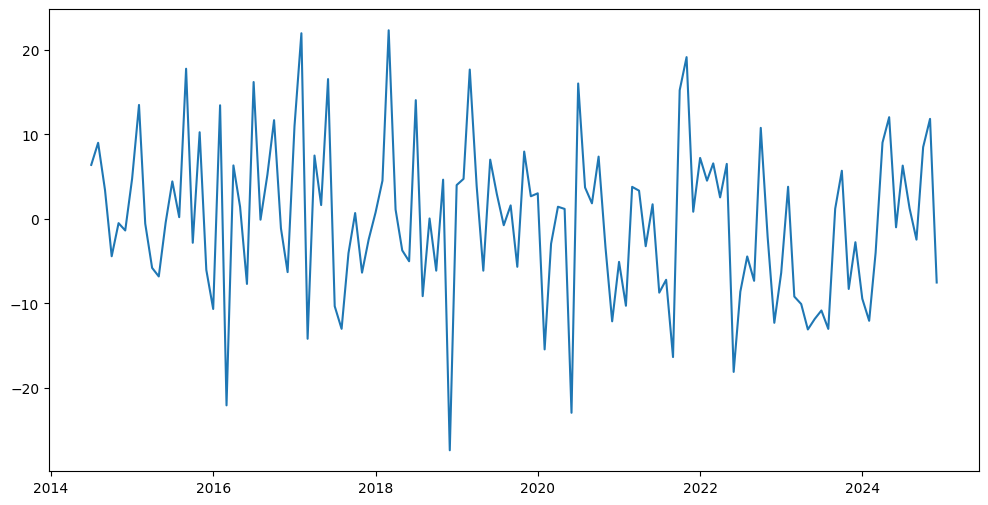

In [131]:
fig = plt.figure(figsize=(12, 6))
plt.plot(results_arima_fp2.resid()[1:],label="Residuales")

======== VALIDACIÓN DE SUPUESTOS ARIMA ========
----------------------------------------------

1. Supuesto de Autocorrelación

Runs Test (aleatoriedad del signo del residuo):
(np.float64(-0.7854988650827044), np.float64(0.4321611354749688))

Ljung-Box y Box-Pierce (lag=1):
    lb_stat  lb_pvalue   bp_stat  bp_pvalue
1  0.090458   0.763596  0.088354    0.76628

Resultados completos Ljung-Box / Box-Pierce:
       lb_stat  lb_pvalue    bp_stat  bp_pvalue  \
1     0.090458   0.763596   0.088354   0.766280   
2     0.295165   0.862791   0.286714   0.866445   
3     0.319834   0.956256   0.310427   0.958056   
4     0.351501   0.986252   0.340620   0.987043   
5     0.351507   0.996561   0.340626   0.996808   
..         ...        ...        ...        ...   
121  71.351096   0.999905  22.931907   1.000000   
122  71.357380   0.999928  22.932151   1.000000   
123  72.093694   0.999929  22.954982   1.000000   
124  76.257309   0.999765  23.051810   1.000000   
125  89.537926   0.992967  23.

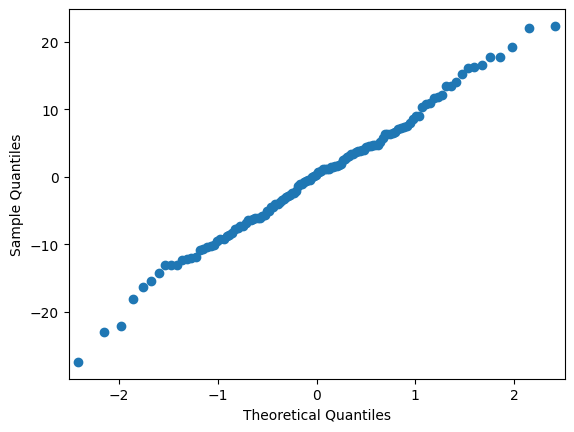

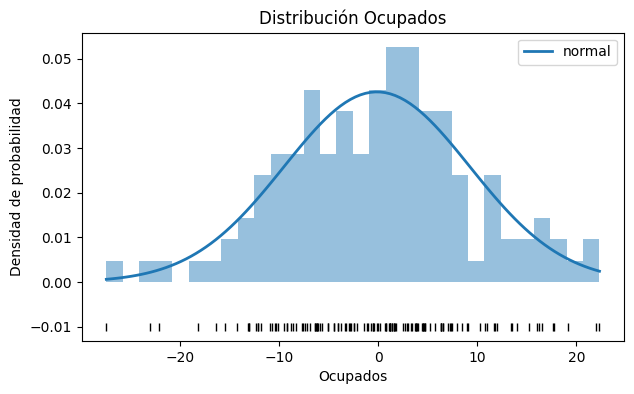

In [132]:
val_supuestos(results_arima_fp2)

Para el **producto2** cumple con **correlacion Autocorrelación** y **Homoscedasticidad y Heteroscedasticidad** teniendo problemas en las pruebas de **Normalidad**.

Este inconveniente puede ser tratado por medio de boostrap que nos puede ayudar a generar intervalos de confianza

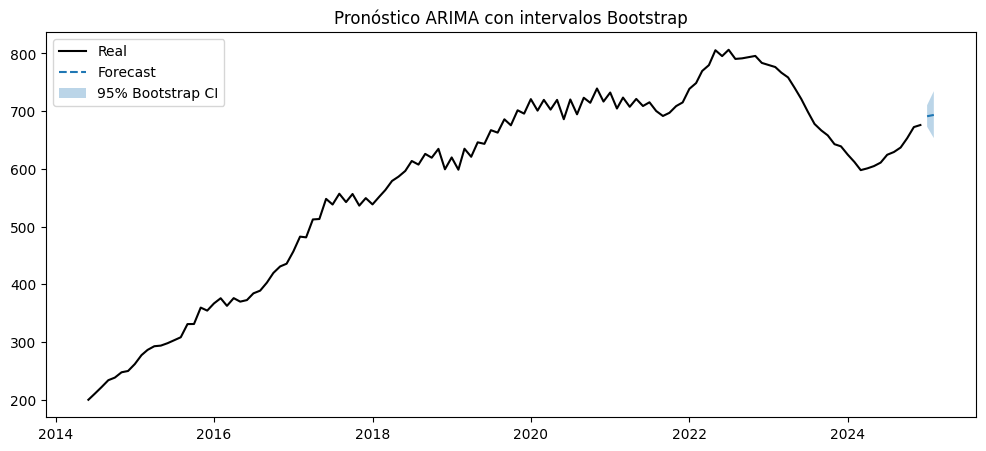

,Point_forecast,lower_95,upper_95
2025-01-01,691.263122,673.151898,710.411260
2025-02-01,693.558107,653.374450,734.681825


In [133]:
preds = bootstrap_forecast(results_arima_fp2, df, h=horizon_size+1, B=1000, colname="producto2")
preds

**ESTModel holt**

In [134]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


In [135]:
end_model_p1 = ETSModel(
    endog=df['producto1'],
    error='mul',
    trend='mul',
    seasonal=None,
)

In [136]:
end_model_fit_p1 = end_model_p1.fit_constrained({
    'smoothing_level': 0.7324821802330145,
    'smoothing_trend': 0.3667550350694303,
    # 'smoothing_seasonal': 0.2282522564558715
})

In [137]:
print(
    end_model_fit_p1.alpha,
    end_model_fit_p1.beta,
    # end_model_fit_p1.gamma
)

0.7324821802330145 0.3667550350694303


In [138]:
feature_end_model_p1 = end_model_fit_p1.forecast(horizon_size+1)

ci_p1 = end_model_fit_p1.get_prediction(
    start= feature_end_model_p1.index[0],
    end= feature_end_model_p1.index[-1]
)

conf_forecast_p1 = ci_p1.pred_int(alpha=0.05)
limits_p1 = ci_p1.predicted_mean

preds_hw_p1 = pd.concat([limits_p1, conf_forecast_p1], axis=1)
preds_hw_p1.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds_hw_p1

,Point_forecast,lower_95,upper_95
2025-01-01,135.852985,128.525288,142.788310
2025-02-01,132.308464,122.421088,143.827649


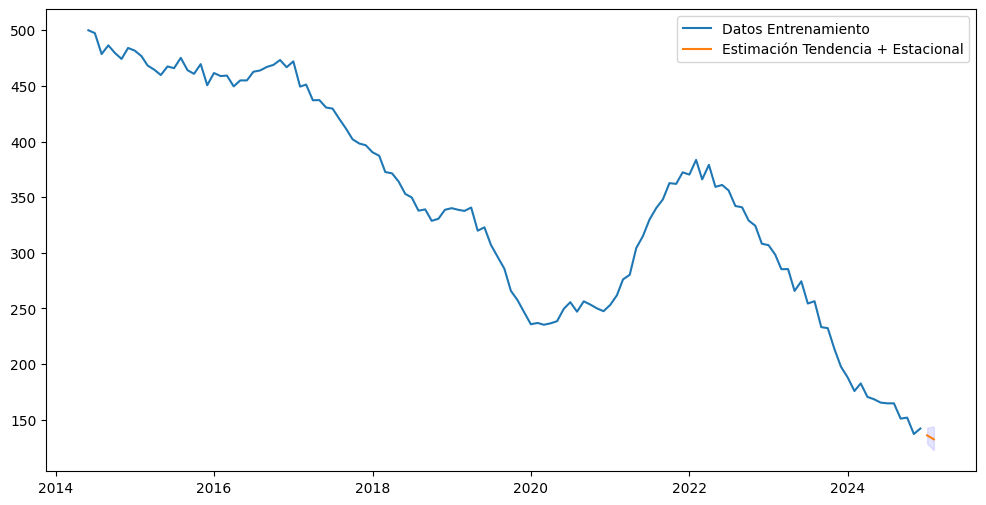

In [139]:
fig = plt.figure(figsize=(12, 6))
plt.plot(df['producto1'],label="Datos Entrenamiento")
plt.plot(preds_hw_p1['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.fill_between(preds_hw_p1.index,preds_hw_p1['lower_95'], preds_hw_p1['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [140]:
# Imprimir los dos mejores modelos encontrados
modelo = {}
for row in df_score_end.iterrows():
    product = row[1]['Producto']
    if product not in modelo:
      modelo[product] = 1
    else:
      modelo[product] += 1

    if modelo[product] < 3:
      print(row[1]['Modelo'], ' -> ', row[1]['Parametros'])

Modelo ARIMA - ventana movil producto1  ->  {'p': 7, 'd': 1, 'q': 10}
ESTModel holt - ventana movil producto1  ->  {'error': 'add', 'trend': 'mul', 'seasonal': None, 'aplha': 0.5408940203078912, 'beta': 0.7292205569221633, 'gamma': 0.39662407398263877}
Modelo ARIMA - ventana movil producto2  ->  {'p': 4, 'd': 1, 'q': 5}
ESTModel holt - ventana movil producto2  ->  {'error': 'add', 'trend': 'add', 'seasonal': 'add', 'aplha': 0.9631842583367579, 'beta': 0.7927585618141351, 'gamma': 0.05496978790136353}


In [141]:
end_model_p2 = ETSModel(
    endog=df['producto2'],
    error='add',
    trend='add',
    seasonal='add',
)

In [142]:
end_model_fit_p2 = end_model_p2.fit_constrained({
    'smoothing_level': 0.730029424673229,
    'smoothing_trend': 0.003334033985698759,
    'smoothing_seasonal': 0.00950635453718085
})

In [143]:
print(
    end_model_fit_p2.alpha,
    end_model_fit_p2.beta,
    end_model_fit_p2.gamma
)

0.730029424673229 0.003334033985698759 0.00950635453718085


In [144]:
feature_end_model_p2 = end_model_fit_p2.forecast(horizon_size+1)

ci_p2 = end_model_fit_p2.get_prediction(
    start= feature_end_model_p2.index[0],
    end= feature_end_model_p2.index[-1]
)

conf_forecast_p2 = ci_p2.pred_int(alpha=0.05)
limits_p2 = ci_p2.predicted_mean

preds_hw_p2 = pd.concat([limits_p2, conf_forecast_p2], axis=1)
preds_hw_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds_hw_p2

,Point_forecast,lower_95,upper_95
2025-01-01,682.298784,653.147772,711.449796
2025-02-01,680.985149,644.835286,717.135013


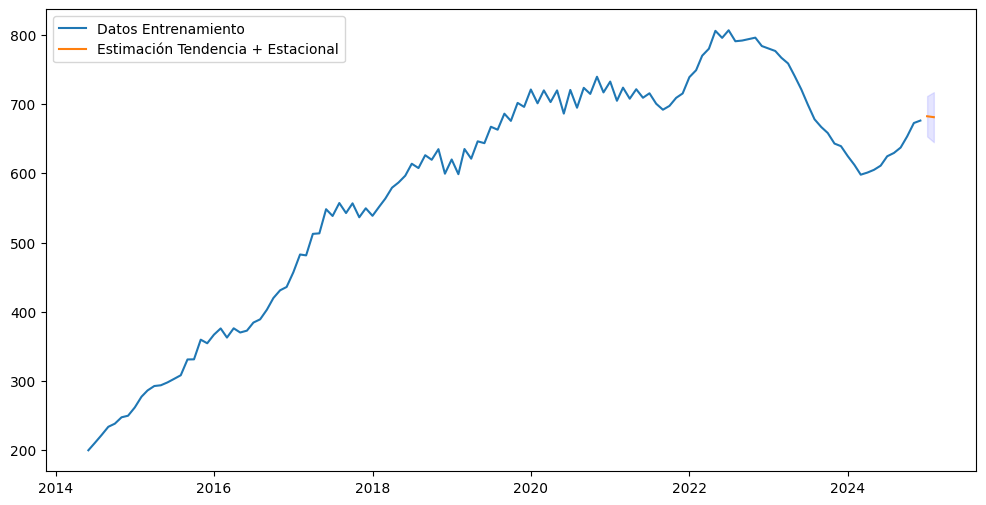

In [145]:
fig = plt.figure(figsize=(12, 6))
plt.plot(df['producto2'],label="Datos Entrenamiento")
plt.plot(preds_hw_p2['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.fill_between(preds_hw_p2.index,preds_hw_p2['lower_95'], preds_hw_p2['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

Como opcion final

In [146]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import optuna
import warnings

# Función de evaluación actualizada para SARIMA
def evaluar_expanding_forecast_sarima(
    serie,
    order,
    seasonal_order,
    window,
    step_size,
    horizon,
    metric='rmse',
    mobile_windows=False
):
    """
    Simula pronósticos SARIMA en tiempo real con ventana expandida/móvil.
    Basado en tu función original 'evaluar_expanding_forecast_arima'.
    """
    # Sanitizar serie
    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)
    predichos = []
    observados = []

    # Índices de entrenamiento
    puntos_finales = list(range(window, n - horizon + 1, step_size))

    for end_train in puntos_finales:
        # Definir train/test
        if mobile_windows:
            train = serie.iloc[end_train - window : end_train]
        else:
            train = serie.iloc[:end_train]

        test = serie.iloc[end_train : end_train + horizon]

        if len(test) < horizon:
            continue

        try:
            # --- CAMBIO PRINCIPAL AQUÍ: Usamos SARIMAX ---
            model = SARIMAX(
                train,
                order=order,              # (p, d, q)
                seasonal_order=seasonal_order, # (P, D, Q, s)
                enforce_stationarity=False,
                enforce_invertibility=False,
                trend='c' # Opcional: añade constante si crees que hay drift
            )
            model_fit = model.fit(disp=False)
            pred = model_fit.forecast(steps=horizon)

        except Exception as e:
            # Si el modelo no converge, saltamos este paso
            continue

        # Filtrar NaN y guardar resultados
        pred = pd.Series(pred).astype(float)
        mask = (~pred.isna()) & (~test.isna())

        if mask.sum() == 0:
            continue

        predichos.extend(pred[mask].tolist())
        observados.extend(test[mask].tolist())

    if len(predichos) == 0:
        return np.inf

    predichos = np.array(predichos)
    observados = np.array(observados)

    # Cálculo de métrica
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    elif metric == 'mae':
        return np.mean(np.abs(observados - predichos))
    else:
        return np.inf

# Función Objetivo de Optuna para SARIMA
def objective_sarima(trial, serie, mobile_windows):
    # 1. Parámetros No Estacionales (p, d, q)
    # Reduje un poco el rango máx de 10 a 5 para que no tarde tanto,
    # pero puedes subirlo si tienes tiempo de cómputo.
    p = trial.suggest_int("p", 0, 5)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 5)

    # 2. Parámetros Estacionales (P, D, Q)
    # Estos suelen ser números bajos (0, 1 o 2).
    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)

    # 3. Periodicidad (s)
    # Fijo en 12 porque tus datos son mensuales y anuales
    s = 12

    order = (p, d, q)
    seasonal_order = (P, D, Q, s)

    # Llamamos a la función de evaluación
    return evaluar_expanding_forecast_sarima(
        serie,
        order,
        seasonal_order,
        window=windows_size,   # Usando tus variables globales
        step_size=step_size,
        horizon=horizon_size,
        mobile_windows=mobile_windows
    )

In [147]:
# Configuración del estudio para Producto 1 (Ventana Móvil)
print("Optimizando SARIMA para Producto 1...")

study_sarima_p1 = optuna.create_study(direction="minimize")

study_sarima_p1.optimize(
    lambda trial: objective_sarima(trial, df['producto1'], mobile_windows=True),
    n_trials=20, # Puedes subir esto a 30 o 50 si tienes tiempo
    n_jobs=-1    # Usa todos los núcleos del procesador
)

print("Mejores parámetros SARIMA P1:", study_sarima_p1.best_params)

# Para visualizarlo usando tu función existente (ajustando el nombre del proceso)
# Nota: Asegúrate de que 'plot_ets_rmse_from_study' pueda leer los params extra
# o simplemente imprime el mejor valor así:
print(f"Mejor RMSE: {study_sarima_p1.best_value}")

[I 2025-12-07 01:50:09,254] A new study created in memory with name: no-name-511704b9-dcb3-4f6d-a70c-6bc54eafbd6b


Optimizando SARIMA para Producto 1...


[I 2025-12-07 01:52:56,690] Trial 1 finished with value: 18.670286688049313 and parameters: {'p': 3, 'd': 0, 'q': 0, 'P': 1, 'D': 1, 'Q': 1}. Best is trial 1 with value: 18.670286688049313.
[I 2025-12-07 01:53:37,877] Trial 2 finished with value: 10.041928162125696 and parameters: {'p': 1, 'd': 1, 'q': 3, 'P': 0, 'D': 1, 'Q': 0}. Best is trial 2 with value: 10.041928162125696.
[I 2025-12-07 01:56:07,412] Trial 0 finished with value: 12.899070721419838 and parameters: {'p': 4, 'd': 2, 'q': 4, 'P': 0, 'D': 1, 'Q': 2}. Best is trial 2 with value: 10.041928162125696.
[I 2025-12-07 01:56:21,559] Trial 3 finished with value: 8.068234818877139 and parameters: {'p': 3, 'd': 1, 'q': 2, 'P': 2, 'D': 0, 'Q': 1}. Best is trial 3 with value: 8.068234818877139.
[I 2025-12-07 01:57:09,431] Trial 5 finished with value: 7.6673925147602295 and parameters: {'p': 2, 'd': 1, 'q': 2, 'P': 1, 'D': 0, 'Q': 0}. Best is trial 5 with value: 7.6673925147602295.
[I 2025-12-07 01:58:33,736] Trial 4 finished with va

Mejores parámetros SARIMA P1: {'p': 2, 'd': 1, 'q': 2, 'P': 1, 'D': 0, 'Q': 1}
Mejor RMSE: 7.607214114493012


Como dato final, también se trabajo al modelo de **SARIMA** obteniendo un **RMSE: 7.61** con los parámetros de **{'p': 2, 'd': 1, 'q': 2, 'P': 1, 'D': 0, 'Q': 1}** donde se puede observar que el modelo tiene un comportamiento similar al de ARIMA, por ende no se reporta en las graficas ya que es un modelo mas complejo y requiere de más computo computacional

In [177]:
# Configuración del estudio para Producto 1 (Ventana Móvil)
print("Optimizando SARIMA para Producto 2...")

study_sarima_p2 = optuna.create_study(direction="minimize")



[I 2025-12-07 03:59:44,905] A new study created in memory with name: no-name-41f850c4-f2c8-4e71-b54d-9e9373eb06f1


Optimizando SARIMA para Producto 2...


In [178]:
study_sarima_p2.optimize(
    lambda trial: objective_sarima(trial, df['producto2'], mobile_windows=True),
    n_trials=20, # Puedes subir esto a 30 o 50 si tienes tiempo
    n_jobs=-1    # Usa todos los núcleos del procesador
)



[I 2025-12-07 04:05:12,537] Trial 0 finished with value: 16.19130977676459 and parameters: {'p': 3, 'd': 1, 'q': 4, 'P': 0, 'D': 1, 'Q': 2}. Best is trial 0 with value: 16.19130977676459.
[I 2025-12-07 04:05:42,468] Trial 1 finished with value: 10.974780851912513 and parameters: {'p': 5, 'd': 0, 'q': 5, 'P': 2, 'D': 0, 'Q': 2}. Best is trial 1 with value: 10.974780851912513.
[I 2025-12-07 04:07:15,029] Trial 2 finished with value: 10.765058404075333 and parameters: {'p': 4, 'd': 1, 'q': 3, 'P': 1, 'D': 0, 'Q': 1}. Best is trial 2 with value: 10.765058404075333.
[I 2025-12-07 04:07:41,938] Trial 4 finished with value: 15.357766471752413 and parameters: {'p': 0, 'd': 1, 'q': 3, 'P': 0, 'D': 1, 'Q': 0}. Best is trial 2 with value: 10.765058404075333.
[I 2025-12-07 04:08:34,234] Trial 3 finished with value: 10.715539233604828 and parameters: {'p': 4, 'd': 1, 'q': 1, 'P': 1, 'D': 0, 'Q': 2}. Best is trial 3 with value: 10.715539233604828.
[I 2025-12-07 04:08:49,882] Trial 5 finished with va

In [179]:
print("Mejores parámetros SARIMA P2:", study_sarima_p2.best_params)

# Para visualizarlo usando tu función existente (ajustando el nombre del proceso)
# Nota: Asegúrate de que 'plot_ets_rmse_from_study' pueda leer los params extra
# o simplemente imprime el mejor valor así:
print(f"Mejor RMSE: {study_sarima_p2.best_value}")

Mejores parámetros SARIMA P2: {'p': 1, 'd': 2, 'q': 1, 'P': 1, 'D': 0, 'Q': 0}
Mejor RMSE: 9.904716385201075


In [148]:
df_score_end = view_score_rmse()
df_score_end

,Producto,Ventana,RMSE,Modelo,Parametros
23,producto1,Movil,7.504303,Modelo ARIMA - ventana movil producto1,"{'p': 7, 'd': 1, 'q': 10}"
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
27,producto1,Movil,11.179243,Modelo PROPHET - ventana movil producto1,{'changepoint_prior_scale': 0.3564315450105214...
12,producto1,Movil,30.554400,Tendencia lienal - ventana movil producto1,{'grado': 4}
8,producto1,Movil,57.704224,Tendencia lienal - ventana movil producto1,{}
19,producto1,Movil,66.756503,Tendencia lineal polinomica que incorpore esta...,{'grado': 4}
15,producto1,Movil,75.757800,Tendencia lineal que incorpore estacionalidad ...,{}
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
24,producto1,Recusiva,7.435670,Modelo ARIMA - ventana recursiva producto1,"{'p': 2, 'd': 1, 'q': 2}"
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."


In [176]:
df_score_end.to_parquet('df_score_end.csv')

In [173]:
df_viz = df_score_end.copy()
df_viz

,Producto,Ventana,RMSE,Modelo,Parametros
23,producto1,Movil,7.504303,Modelo ARIMA - ventana movil producto1,"{'p': 7, 'd': 1, 'q': 10}"
4,producto1,Movil,8.246065,ESTModel holt - ventana movil producto1,"{'error': 'add', 'trend': 'mul', 'seasonal': N..."
27,producto1,Movil,11.179243,Modelo PROPHET - ventana movil producto1,{'changepoint_prior_scale': 0.3564315450105214...
12,producto1,Movil,30.554400,Tendencia lienal - ventana movil producto1,{'grado': 4}
8,producto1,Movil,57.704224,Tendencia lienal - ventana movil producto1,{}
19,producto1,Movil,66.756503,Tendencia lineal polinomica que incorpore esta...,{'grado': 4}
15,producto1,Movil,75.757800,Tendencia lineal que incorpore estacionalidad ...,{}
0,producto1,Movil,78.872288,Promedio Mobil - ventana movil producto1,{}
24,producto1,Recusiva,7.435670,Modelo ARIMA - ventana recursiva producto1,"{'p': 2, 'd': 1, 'q': 2}"
5,producto1,Recusiva,8.194525,ESTModel holt - ventana recursiva producto1,"{'error': 'mul', 'trend': 'mul', 'seasonal': N..."


In [151]:
import seaborn as sns

In [169]:
def format_dict_two_per_line(d):
    if not isinstance(d, dict):
        return str(d)

    items = list(d.items())
    lineas = []

    for i in range(0, len(items), 2):
        bloque = items[i:i+2]
        linea = " -> ".join([f"{k}: {v}" for k, v in bloque])
        lineas.append(linea)

    return "\n".join(lineas)





(15, 5)


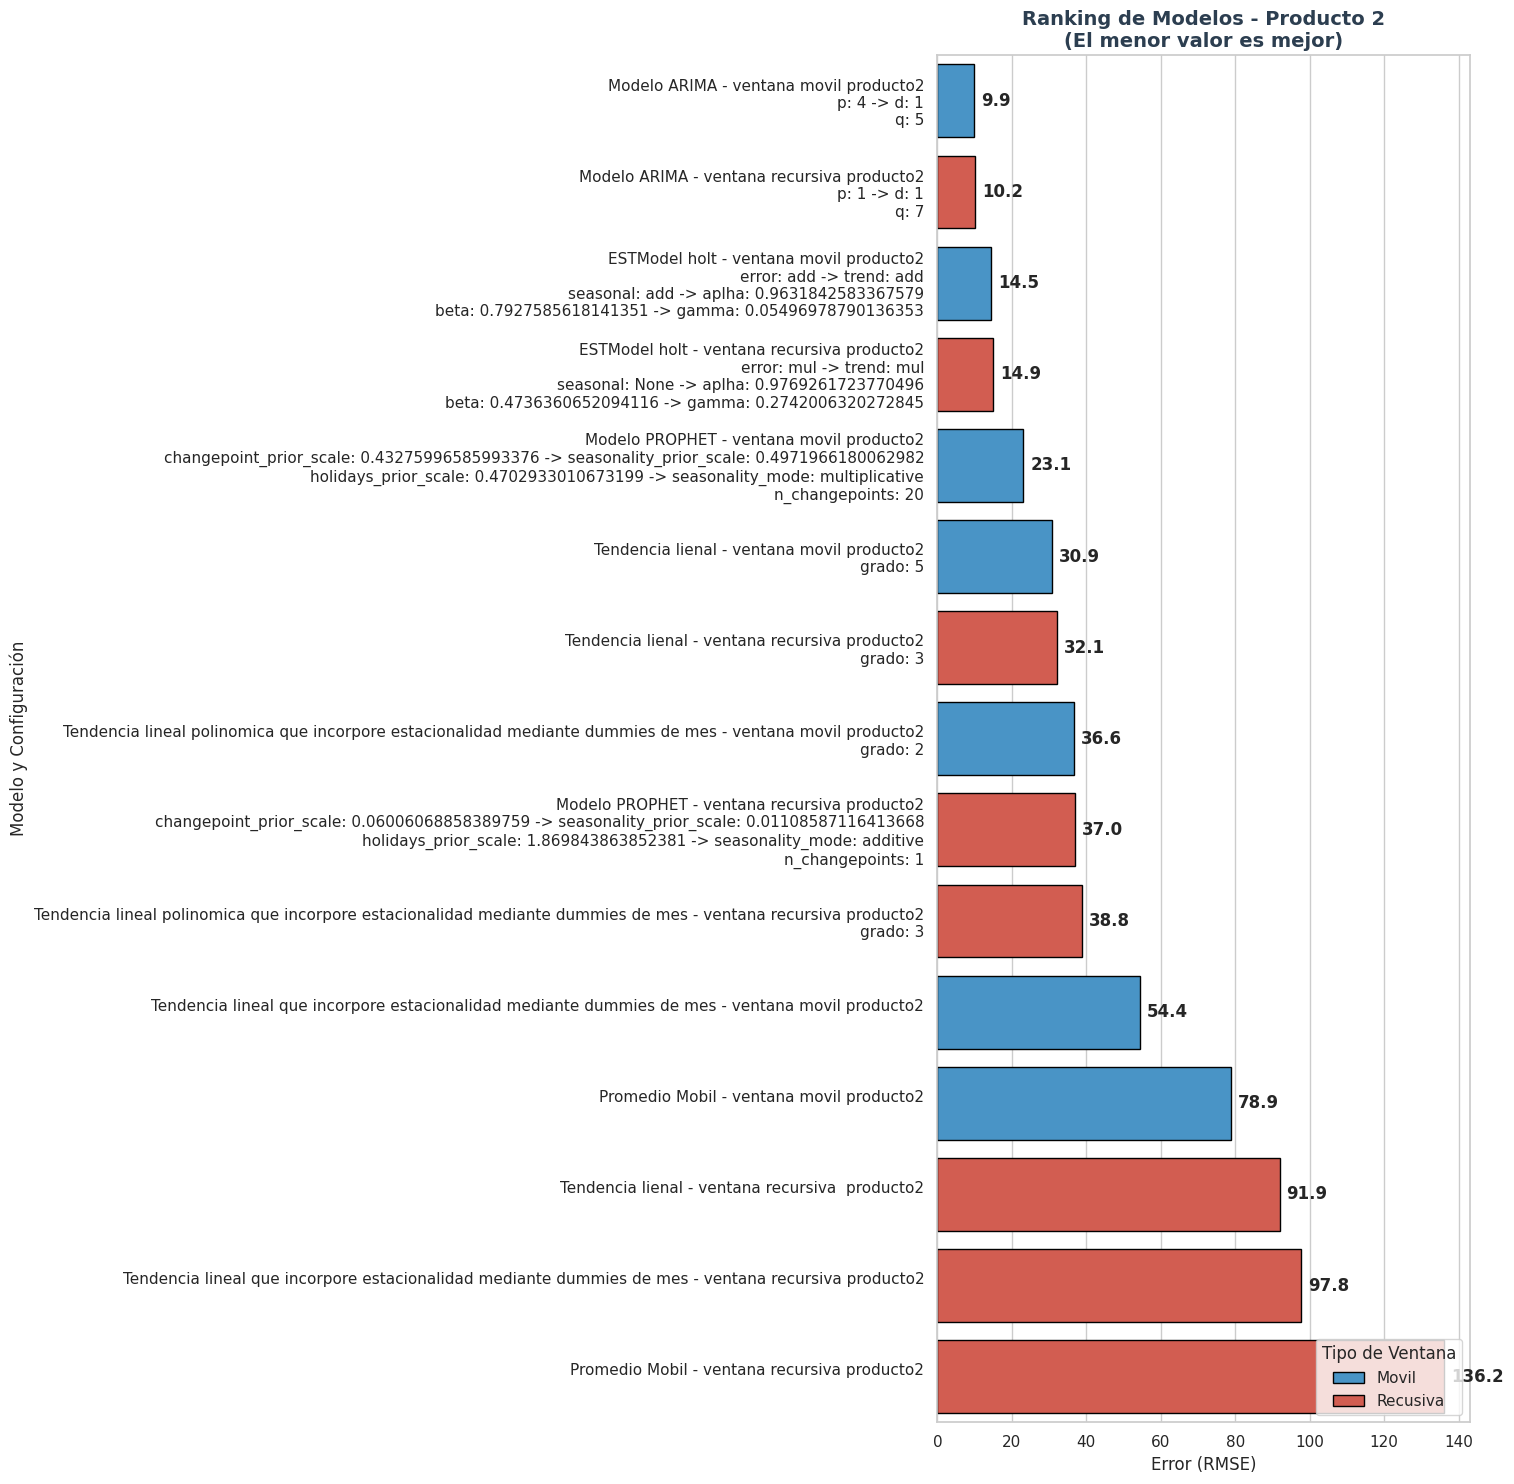

In [174]:
p2_data = df_viz.copy()
p2_data = df_viz[df_viz['Producto'] == 'producto2'].sort_values('RMSE')

print(p2_data.shape)
# 2. Lógica de limpieza y formateo (Corrigiendo la sintaxis del usuario)
# Nota: Como definimos los nombres limpios arriba, el replace no hará nada pero lo dejamos por consistencia
# p2_data['Modelo'] = p2_data['Modelo'].str.replace('producto2', '', regex=False).str.strip()

# Concatenación correcta de columnas en pandas, explicitly convert 'Parametros' to string
p2_data['Modelo'] = p2_data['Modelo'] + '\n' + p2_data['Parametros'].apply(format_dict_two_per_line)

# Ordenar
p2_data = p2_data.sort_values('RMSE')

# 3. Configuración de la gráfica
plt.figure(figsize=(15, 15)) # Ajusté un poco el ancho para que se vea bien en el notebook
sns.set_theme(style="whitegrid")
palette = {"Movil": "#3498db", "Recusiva": "#e74c3c"} # Corrected 'Recursiva' to 'Recusiva'

ax2 = sns.barplot(
    data=p2_data, # Filter for producto2
    x='RMSE',
    y='Modelo',
    hue='Ventana',
    palette=palette,
    edgecolor='black',
    dodge=False
)

plt.title('Ranking de Modelos - Producto 2\n(El menor valor es mejor)', fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel('Error (RMSE)', fontsize=12)
plt.ylabel('Modelo y Configuración', fontsize=12)
plt.legend(title='Tipo de Ventana', loc='lower right')

# Etiquetas de valor
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=5, fontweight='bold')

plt.tight_layout()
plt.savefig('ranking_producto2_final.png')
plt.show()

(16, 5)


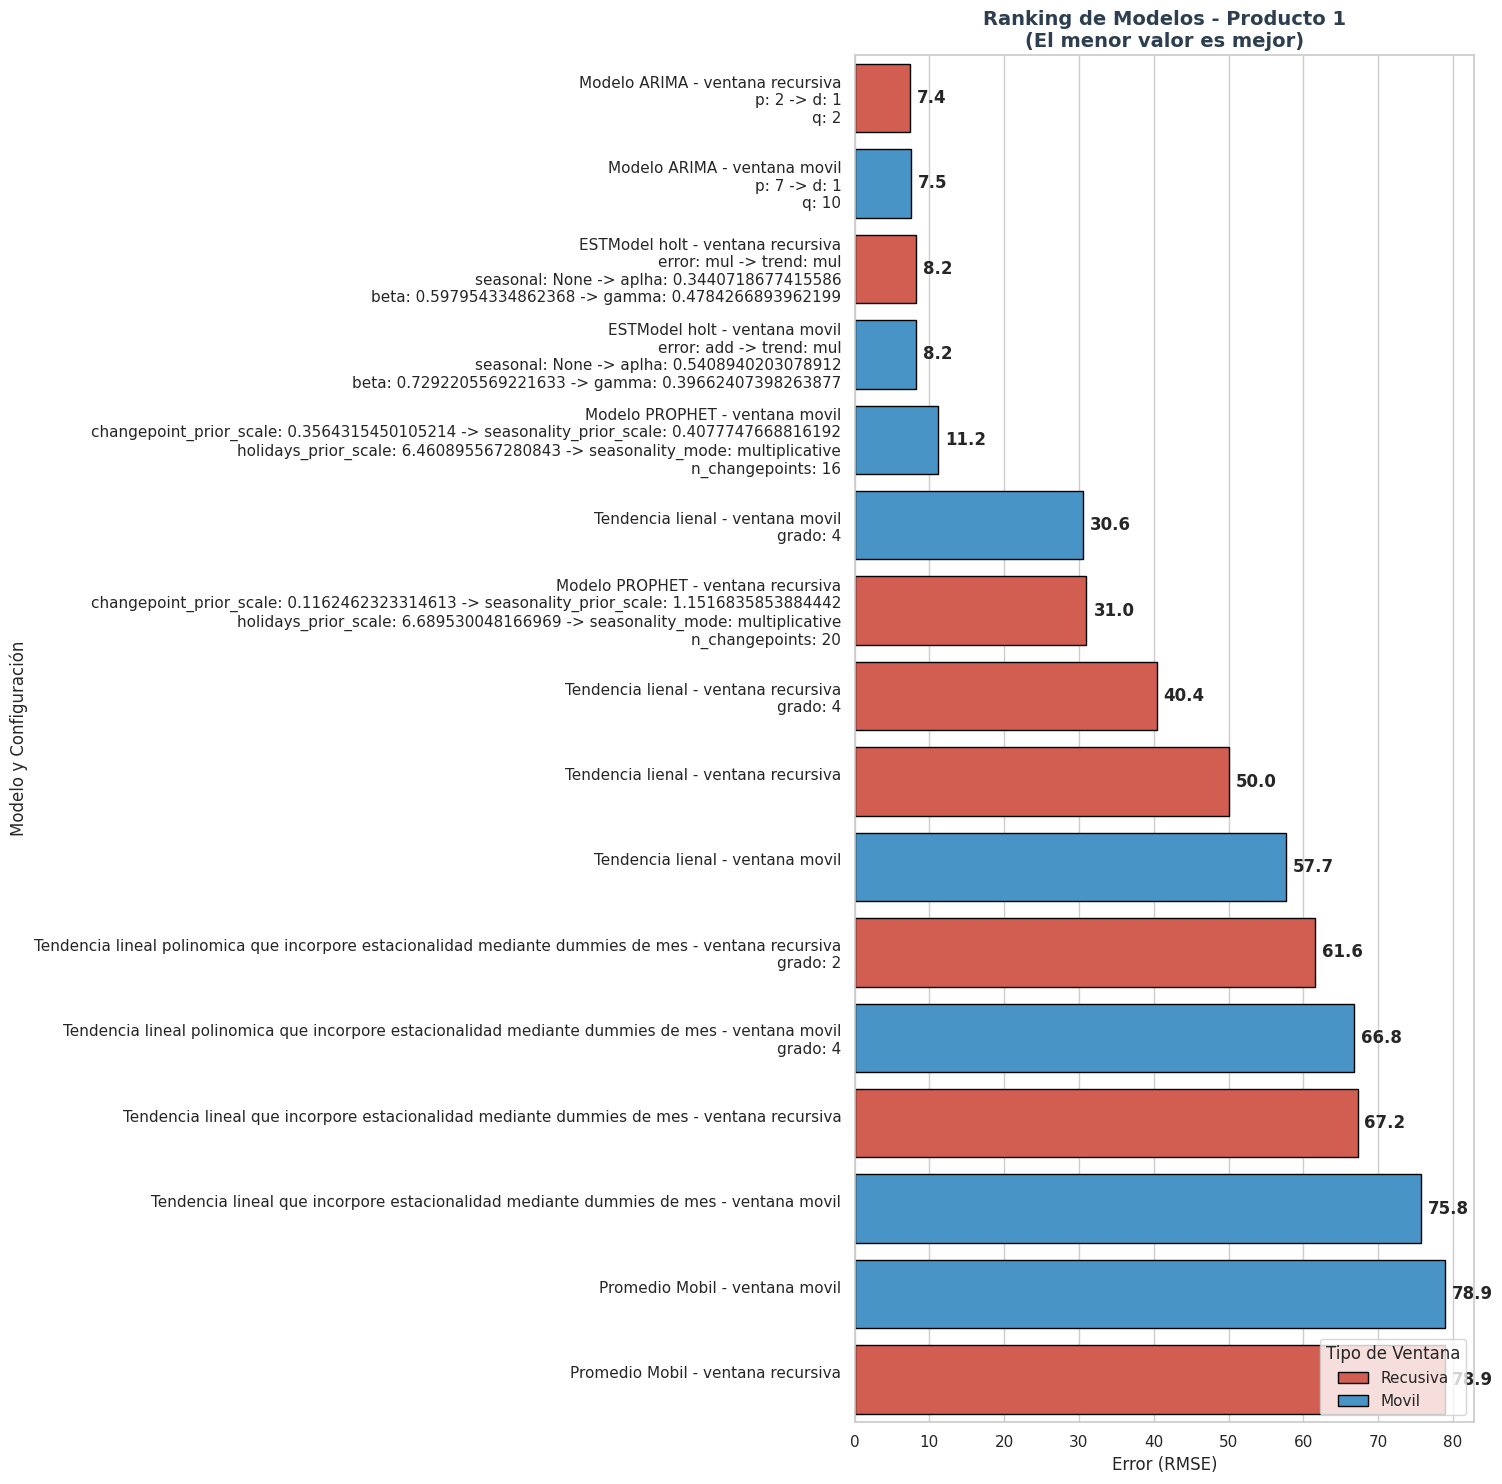

In [166]:
p2_data = df_viz.copy()
p2_data = df_viz[df_viz['Producto'] == 'producto1'].sort_values('RMSE')

print(p2_data.shape)
# 2. Lógica de limpieza y formateo (Corrigiendo la sintaxis del usuario)
# Nota: Como definimos los nombres limpios arriba, el replace no hará nada pero lo dejamos por consistencia
p2_data['Modelo'] = p2_data['Modelo'].str.replace('producto1', '', regex=False).str.strip()

# Concatenación correcta de columnas en pandas, explicitly convert 'Parametros' to string
p2_data['Modelo'] = p2_data['Modelo'] + '\n' + p2_data['Parametros'].apply(format_dict_two_per_line)

# Ordenar
p2_data = p2_data.sort_values('RMSE')

# 3. Configuración de la gráfica
plt.figure(figsize=(15, 15)) # Ajusté un poco el ancho para que se vea bien en el notebook
sns.set_theme(style="whitegrid")
palette = {"Movil": "#3498db", "Recusiva": "#e74c3c"} # Corrected 'Recursiva' to 'Recusiva'

ax2 = sns.barplot(
    data=p2_data, # Filter for producto2
    x='RMSE',
    y='Modelo',
    hue='Ventana',
    palette=palette,
    edgecolor='black',
    dodge=False
)

plt.title('Ranking de Modelos - Producto 1\n(El menor valor es mejor)', fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel('Error (RMSE)', fontsize=12)
plt.ylabel('Modelo y Configuración', fontsize=12)
plt.legend(title='Tipo de Ventana', loc='lower right')

# Etiquetas de valor
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=5, fontweight='bold')

plt.tight_layout()
plt.savefig('ranking_producto1_final.png')
plt.show()

In [ ]:
# Imprimir los dos mejores modelos encontrados
modelo = {}
for row in df_score_end.iterrows():
    product = row[1]['Producto']
    if product not in modelo:
      modelo[product] = 1
    else:
      modelo[product] += 1

    if modelo[product] < 3:
      print(row[1]['Modelo'], ' -> ', row[1]['Parametros'])